# SIGMA vs CellID / scGate / UCell / SingleR / ScType - Tem cytotoxic T cell extraction
## Dominguez et al. cross-tissue human immune atlas (Science, 2022)

**Comparison of SIGMA against three marker-based annotation methods
(UCell, CellID, scGate), one reference-based classifier (SingleR), and one
marker-based per-cell scoring method (ScType) for the targeted extraction
of effector memory cytotoxic T cells.** This notebook loads the data once,
scores all comparator methods back to back, and reuses one set of generic
plotting/statistics utilities.

### Methods compared
- **UCell** (v2): continuous per-cell score, thresholded at a percentile.
  Positive (target) and negative (exclusion) markers are combined natively
  into a single signature with `+`/`-` suffixes.
- **CellID**: per-cell hypergeometric enrichment test (`RunCellHGT`) against
  positive (`target`) and negative (`exclusion`) gene sets, run via Seurat/R
  through rpy2. Target and exclusion are two independent hypergeometric
  tests, not a single combined score - the only comparator here without a
  native exclusion mechanism, along with SingleR.
- **scGate** (R/Seurat, built on UCell): combines the positive and negative
  signature into a single gating model (`gating_model(..., negative =
  TRUE)`) and returns a hard purity label `is.pure` (`Pure`/`Impure`) from
  its own internal gating (UCell scores + kNN smoothing + adaptive
  thresholds) - no percentile cutoff is chosen by hand. UCell and ScType
  (below) also combine positive/negative markers natively, each into a
  single continuous score thresholded at a percentile; scGate is the only
  one of the three that outputs a hard label instead.
- **SingleR** (Aran et al., Nature Immunology 2019): reference-based
  correlation classifier against the Monaco et al. 2019 immune reference
  (`celldex::MonacoImmuneData()`, fine-grained labels). Cells are labelled
  `SingleR+` when their assigned label falls in the effector-memory /
  terminally-differentiated cytotoxic CD8+ compartment (see Configuration).
- **ScType** (Ianevski et al., Nature Communications 2022): marker-based
  per-cell scoring (`sctype_score()`, vendored from
  https://github.com/IanevskiAleksandr/sc-type) combining positive (Target)
  and negative (LowIn) gene set contributions on scaled expression data into
  a single continuous score per cell, thresholded at a percentile like
  UCell/CellID.

### Model / signatures
All methods use the same Target / Exclusion signature
(`config/StudyCaseDominguez.conf`: `[Target]` / `[LowIn]`):
- positive (Target): GZMK, GZMB, NKG7, PRF1, CX3CR1, IL7R, CD44
- negative (LowIn/Exclusion): CCR7, SELL, TCF7, LEF1, CXCR5, CD27, FOXP3, TRDC, TRGC1, TRGC2

### Datasets
- Full dataset: Dominguez Conde et al., Science 2022 (doi: 10.1126/science.abl5197)
- SIGMA output: `merge.h5ad` produced by the SIGMA pipeline (score threshold >= 0.95)

### References
- UCell: Andreatta & Carmona, Computational and Structural Biotechnology Journal 2021 (doi: 10.1016/j.csbj.2021.06.043)
- scGate: Andreatta et al., Bioinformatics 2022 (doi: 10.1093/bioinformatics/btac141)
- SingleR: Aran et al., Nature Immunology 2019 (doi: 10.1038/s41590-018-0276-y)
- ScType: Ianevski et al., Nature Communications 2022 (doi: 10.1038/s41467-022-28803-w)

### Validation approach
Selections are evaluated using three marker panels, chosen to be disjoint from
all three gene lists SIGMA uses to decide which cells are positive
(`CANDIDATE_GENES`, `TARGET_GENES`, `EXCLUSION_GENES`), so that no method is
scored against its own decision criterion:
- Pan-T cell identity markers (CD3D, CD3G, TRBC1, TRBC2, CD5)
- NK cell contamination markers (NCAM1, KLRD1, FCGR3A, GNLY)
- Non-effector T cell markers (CD4, CD40LG, CD28, MAL, BACH2)

**On the candidate prefilter.** SIGMA restricts scoring to cells expressing at
least 3 of CD3E, TRAC, CD8A and CD8B at 2 raw counts, which reduces the search
space and limits false positives arising from stochastic detection of target
genes in unrelated cells (article, "Selection of candidate cells"). Those four
genes are part of SIGMA's decision procedure, so its calls satisfy them by
construction and they cannot validate its output - even though no comparator
receives them. The identity panel above therefore uses pan-T genes instead;
CD8A and CD8B have no non-candidate equivalent, so it establishes T lineage
rather than CD8 lineage. What the prefilter actually buys is reported
separately, in the candidate-prefilter diagnostic figure.

Two supplementary, clearly separate figures (exclusion-compliance and
candidate-prefilter diagnostics) deliberately use genes overlapping SIGMA's
decision lists - see their own markdown cells for why that makes them
diagnostics, not validations.

There is no universally accepted ground truth for single-cell annotation, so
this evaluates biological coherence (marker expression) rather than
agreement with a "true" label.

### Prerequisites (documented only - nothing in this notebook installs anything)
- Python: `rpy2` (`pip install rpy2`), `pyucell`
- R, reachable from this Python environment, with `Seurat`, `Matrix`, `CelliD`, `scGate`, `SingleR`, `SingleCellExperiment`,
  `SummarizedExperiment` and `scuttle` installed:
  ```r
  install.packages(c("Seurat", "Matrix", "scGate"))  # scGate pulls UCell as a dependency
  BiocManager::install(c("CelliD", "SingleR", "SingleCellExperiment", "SummarizedExperiment", "scuttle"))
  ```
- ScType is not a package: its `sctype_score()` is vendored locally in `snotebooks/sctype_R/`.

### Output figures
The only figure file written is `figures/FIG-combined.pdf`, the A-F
composite (upset, Jaccard, T cell, non-effector, NK, purity). Each panel is
also built individually earlier in the notebook (including the
exclusion-compliance and candidate-prefilter diagnostics, neither part of
the composite) for inspection
while running, but those individual `savefig` calls are commented out by
design - only the combined figure is a deliverable.

The threshold sensitivity check for the composition/purity panel (4
candidate thresholding scenarios) is exported to
`results/dominguez_threshold_sensitivity.csv`.

### Notebook structure
Setup and configuration, then shared data loading/normalization/utility
functions, then scoring back to back (CellID -> scGate -> UCell -> SingleR
-> ScType), then saving scoring results to disk (with an optional reload),
then comparison figures across all 6 groups.


In [1]:
import os

# --- Adjust to your environment ---
# Conda env providing R and the R packages used below (Seurat, CelliD,
# scGate, SingleR, SingleCellExperiment). Override via env var instead of
# editing this cell if running elsewhere.
SIGMA_ENV = os.environ.get("SIGMA_ENV", "/home/lemgui01/.miniconda3/envs/sigma_compare")

os.environ["R_HOME"] = f"{SIGMA_ENV}/lib/R"
os.environ["R_DEFAULT_PACKAGES"] = "datasets,utils,grDevices,graphics,stats,methods"
os.environ["PATH"] = f"{SIGMA_ENV}/bin:" + os.environ.get("PATH", "")
# Put the env's own lib/ before R/lib so the conda libstdc++ (newer CXXABI)
# wins over the system one; otherwise scipy/sklearn fail to load.
os.environ["LD_LIBRARY_PATH"] = (
    f"{SIGMA_ENV}/lib:{SIGMA_ENV}/lib/R/lib:" + os.environ.get("LD_LIBRARY_PATH", "")
)
os.environ["LC_ALL"] = "C"
os.environ["LANG"] = "C"

import numpy as np
import scipy.sparse as sp
import scipy.io as sio
import scanpy as sc
import pandas as pd
from scipy.stats import mannwhitneyu
from pyucell import compute_ucell_scores
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import io
import shutil

from upsetplot import UpSet, from_indicators
from statsmodels.stats.multitest import multipletests
from skimage.filters import threshold_otsu
from sklearn.mixture import GaussianMixture

import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

print("rpy2 libPaths:", list(ro.r('.libPaths()')))

r_matrix = importr("Matrix")  # used below (r_matrix.sparseMatrix)
# Imported for their side effect of loading the R package into the R
# session; called from R code strings below, never referenced from Python.
importr("Seurat")
importr("CelliD")
importr("scGate")
importr("SingleR")
importr("SingleCellExperiment")

# ScType functions are vendored locally (sctype_R/)
SCTYPE_SCRIPT = os.path.join(os.getcwd(), "sctype_R", "sctype_score_.R")
ro.r(f'source("{SCTYPE_SCRIPT}")')

print("✅ rpy2 + R packages + ScType loaded.")

# --- upsetplot 0.9.0 / pandas>=3 compatibility patch ---
# UpSet.plot_matrix does `styles[col].fillna(value, inplace=True)`, which is a
# silent no-op under pandas>=3 Copy-on-Write (upstream bug, not yet fixed in
# upsetplot 0.9.0, the latest release). Left unpatched, styles["edgecolor"]
# keeps NaN and matplotlib crashes with "Invalid RGBA argument: nan". This
# patch is byte-for-byte the original method with only the 4 fillna calls
# changed to explicit reassignment.
import upsetplot.plotting as _upsetplot_plotting

def _patched_plot_matrix(self, ax):
    ax = self._reorient(ax)
    data = self.intersections
    n_cats = data.index.nlevels
    inclusion = data.index.to_frame().values

    styles = [
        [
            self.subset_styles[i]
            if inclusion[i, j]
            else {"facecolor": self._other_dots_color, "linewidth": 0}
            for j in range(n_cats)
        ]
        for i in range(len(data))
    ]
    styles = sum(styles, [])
    style_columns = {
        "facecolor": "facecolors", "edgecolor": "edgecolors",
        "linewidth": "linewidths", "linestyle": "linestyles", "hatch": "hatch",
    }
    styles = (
        pd.DataFrame(styles)
        .reindex(columns=style_columns.keys())
        .astype({"facecolor": "O", "edgecolor": "O", "linewidth": float,
                 "linestyle": "O", "hatch": "O"})
    )
    styles["linewidth"] = styles["linewidth"].fillna(1)
    styles["facecolor"] = styles["facecolor"].fillna(self._facecolor)
    styles["edgecolor"] = styles["edgecolor"].fillna(styles["facecolor"])
    styles["linestyle"] = styles["linestyle"].fillna("solid")
    del styles["hatch"]

    x = np.repeat(np.arange(len(data)), n_cats)
    y = np.tile(np.arange(n_cats), len(data))
    s = (self._element_size * 0.35) ** 2 if self._element_size is not None else 200
    ax.scatter(
        *self._swapaxes(x, y), s=s, zorder=10,
        **styles.rename(columns=style_columns),
    )

    if self._with_lines:
        idx = np.flatnonzero(inclusion)
        line_data = (
            pd.Series(y[idx], index=x[idx]).groupby(level=0).aggregate(["min", "max"])
        )
        colors = pd.Series(
            [style.get("edgecolor", style.get("facecolor", self._facecolor))
             for style in self.subset_styles],
            name="color",
        )
        line_data = line_data.join(colors)
        ax.vlines(line_data.index.values, line_data["min"], line_data["max"],
                   lw=2, colors=line_data["color"], zorder=5)

    tick_axis = ax.yaxis
    tick_axis.set_ticks(np.arange(n_cats))
    tick_axis.set_ticklabels(data.index.names, rotation=0 if self._horizontal else -90)
    ax.xaxis.set_visible(False)
    ax.tick_params(axis="both", which="both", length=0)
    if not self._horizontal:
        ax.yaxis.set_ticks_position("top")
    ax.set_frame_on(False)
    ax.set_xlim(-0.5, x[-1] + 0.5, auto=False)
    ax.grid(False)

_upsetplot_plotting.UpSet.plot_matrix = _patched_plot_matrix


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
rpy2 libPaths: ['/home/lemgui01/R/x86_64-conda-linux-gnu-library/4.5', '/home/lemgui01/.miniconda3/envs/sigma_compare/lib/R/library']
✅ rpy2 + R packages + ScType loaded.


---
## Configuration

In [ ]:
# --- Adjust to your environment ---
PATH_FULL  = "/mnt/projects_tn03/AD_EB_singlecell/articleSIGMA_results-2/Dominguez-Data/Dominguez_science_science-abl5197.h5ad"
PATH_SIGMA = "/mnt/projects_tn03/AD_EB_singlecell/articleSIGMA_results-2/output/results_Dominguez/merge.h5ad"
os.makedirs("figures", exist_ok=True)

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# --- SIGMA threshold ---
SIGMA_THRESHOLD = 0.95

# --- Gene sets, shared by the 5 methods (config/StudyCaseDominguez.conf: [Target] / [LowIn]) ---
TARGET_GENES = ["GZMK", "GZMB", "NKG7", "PRF1", "CX3CR1", "IL7R", "CD44"]

EXCLUSION_GENES = ["CCR7", "SELL", "TCF7", "LEF1", "CXCR5", "CD27", "FOXP3",
                    "TRDC", "TRGC1", "TRGC2"]

# UCell v2 combined signature with +/- suffixes
TEM_UCELL_COMBINED = ([f"{g}+" for g in TARGET_GENES] +
                      [f"{g}-" for g in EXCLUSION_GENES])

# --- Per-method thresholds ---
UCELL_PERCENTILE = 99
CELLID_HGT_THRESHOLD_PERCENTILE = 99
# scGate returns a hard is.pure label; no percentile cutoff

# --- SIGMA candidate genes (NOT a validation panel) ---
CANDIDATE_GENES = ["CD3E", "TRAC", "CD8A", "CD8B"]

# --- Validation marker panels ---
T_CELL_MARKERS = ["CD3D", "CD3G", "TRBC1", "TRBC2", "CD5"]
NK_MARKERS = ["NCAM1", "KLRD1", "FCGR3A", "GNLY"]
NON_EFFECTOR_MARKERS = ["CD4", "CD40LG", "CD28", "MAL", "BACH2"]
# Supplementary diagnostic panel only (see its markdown cell) - deliberately
# overlaps EXCLUSION_GENES, so NOT an independent validation panel.
EXCLUSION_COMPLIANCE_MARKERS = ["CD4", "FOXP3", "TCF7", "SELL"]

# Guard: a validation panel must never contain a gene SIGMA used to decide
# which cells are positive. CANDIDATE_GENES and EXCLUSION_COMPLIANCE_MARKERS
# are deliberately outside the check - their overlap with the decision lists is
# what makes them diagnostics rather than validations.
DECISION_GENES = set(CANDIDATE_GENES) | set(TARGET_GENES) | set(EXCLUSION_GENES)
for _name, _panel in [("T_CELL_MARKERS", T_CELL_MARKERS),
                      ("NK_MARKERS", NK_MARKERS),
                      ("NON_EFFECTOR_MARKERS", NON_EFFECTOR_MARKERS)]:
    _overlap = DECISION_GENES.intersection(_panel)
    assert not _overlap, (
        f"{_name} overlaps SIGMA's decision genes {sorted(_overlap)}: a "
        "validation panel must not contain any gene the method used to decide "
        "which cells are positive"
    )

# --- Plot colors ---
BLUE   = "#1f77b4"  # SIGMA+
ORANGE = "#e67e22"  # UCell+
PURPLE = "#9467bd"  # CellID+
GREEN  = "#2ca02c"  # scGate+
PINK   = "#e377c2"  # SingleR+
BROWN  = "#8c564b"  # ScType+
SEED = 42  # bootstrap CI / jitter subsampling, re-seeded per panel

# --- CellID perf knobs ---
MIN_CELLS_PER_GENE = 10   # pre-MCA min-count filter
# Cap genes: RunMCA densifies via 32-bit Armadillo, crashes past ~2^31
# elements (genes x cells). Stay under ~6500 genes for 329k cells - this
# does bind (the dataset has far more than 5000 detected genes after the
# min-count filter), so CellID's MCA runs on a 5000-gene subset while the
# other methods see the full transcriptome. Documented here as a
# limitation, not a hypothetical.
MAX_GENES_MCA = 5000
# Scratch dir for the on-disk counts transfer to R. The .mtx export is large
# (~9 GB for CellID, ~2.5 GB for SingleR), so keep it off a small /tmp.
SCRATCH_DIR = os.path.expanduser("~/sigma_scratch/dominguez_transfer")
TMP_DIR = os.path.join(SCRATCH_DIR, "cellid")
os.makedirs(TMP_DIR, exist_ok=True)

# --- scGate perf knobs ---
# scGate's internal ScaleData/RunPCA on the full transcriptome dominates
# runtime. Filter genes upstream and lower nfeatures/pca.dim (defaults
# 2000/30); safe for a single-level gate as long as signature genes remain.
SCGATE_MIN_CELLS_PER_GENE = 30
SCGATE_NFEATURES = 1000
SCGATE_PCA_DIM = 15
# scGate's internal PCA/kNN seed (package default 123), explicit for reproducibility
SCGATE_SEED = 123

# --- SingleR reference (local .rds cache) ---
# HTTPS is intercepted here, so celldex can't download the reference.
# Fetch it elsewhere and copy to SINGLER_REF_RDS (see singler_R/README.md).
SINGLER_REF_RDS = "singler_R/monaco_immune.rds"
SINGLER_LABEL_COLUMN = "label.fine"  # "label.fine" (Monaco fine-grained) or "label.main"

# Monaco label.fine values for the effector-memory / terminal cytotoxic CD8+ compartment
SINGLER_TARGET_LABELS = [
    "Effector memory CD8 T cells",
    "Terminal effector CD8 T cells",
]

TMP_DIR_SINGLER = os.path.join(SCRATCH_DIR, "singler")
os.makedirs(TMP_DIR_SINGLER, exist_ok=True)

# --- ScType threshold ---
# ScType gives a continuous per-cell score, thresholded at P99 like CellID/UCell
SCTYPE_SCORE_PERCENTILE = 99


---
## 1. Data loading (shared across all comparisons)

In [4]:
adata_full  = sc.read_h5ad(PATH_FULL)
adata_sigma = sc.read_h5ad(PATH_SIGMA)

print(f"adata_full  : {adata_full.shape[0]:,} cells x {adata_full.shape[1]:,} genes")
print(f"adata_sigma : {adata_sigma.shape[0]:,} cells x {adata_sigma.shape[1]:,} genes")


adata_full  : 329,762 cells x 36,601 genes
adata_sigma : 41,214 cells x 36,601 genes


---
## 2. SIGMA+ labeling (shared across all comparisons)

In [5]:
adata_sigma_thresh = adata_sigma[adata_sigma.obs["score"] >= SIGMA_THRESHOLD].copy()

adata_sigma_thresh.obs_names = adata_sigma_thresh.obs_names.str.replace(
    r"-Dominguez_.*?_data$", "", regex=True
)

adata_full.obs["sigma_positive"] = adata_full.obs_names.isin(set(adata_sigma_thresh.obs_names))

mask_sigma = adata_full.obs["sigma_positive"]
print(f"SIGMA+ : {mask_sigma.sum():,}")


SIGMA+ : 2,509


---
## 3. log1p-CPM normalization (shared across all comparisons)

In [6]:
adata_norm = adata_full.copy()
sc.pp.normalize_total(adata_norm, target_sum=1e6)
sc.pp.log1p(adata_norm)


---
## 4. Utility functions (shared across all comparisons)

In [7]:
def style_upset_axes(axes):
    """Cosmetic tweaks applied to an UpSet.plot() axes dict: rotate the
    per-method totals bar labels to vertical (they collide horizontally at
    this figure width), and widen the intersection-size axis so bar-end
    labels aren't flush against the bars."""
    for t in axes["totals"].texts:
        t.set_rotation(90)
    xlim = axes["intersections"].get_xlim()
    axes["intersections"].set_xlim(xlim[0], xlim[1] * 1.15)

def mean_panel(adata, mask, genes):
    """Compute the mean expression of a list of genes for a given mask."""
    genes_ok = [g for g in genes if g in adata.var_names]
    missing = set(genes) - set(genes_ok)
    if missing:
        print(f"mean_panel: gene(s) not in dataset, dropped: {sorted(missing)}")
    if not genes_ok:
        return np.zeros(int(mask.sum()))
    idx = [adata.var_names.get_loc(g) for g in genes_ok]
    expr = adata.X[mask][:, idx]
    if hasattr(expr, "toarray"):
        expr = expr.toarray()
    return np.mean(expr, axis=1)

def panel_score(genes):
    """Mean log1p-CPM across a marker panel, per cell (over all of adata_norm)."""
    genes_ok = [g for g in genes if g in adata_norm.var_names]
    missing = set(genes) - set(genes_ok)
    if missing:
        print(f"panel_score: gene(s) not in dataset, dropped: {sorted(missing)}")
    idx = [adata_norm.var_names.get_loc(g) for g in genes_ok]
    expr = adata_norm.X[:, idx]
    if hasattr(expr, "toarray"):
        expr = expr.toarray()
    return np.asarray(np.mean(expr, axis=1)).flatten()

def composition_purity_table(criteria_pass, method_masks_full, method_labels):
    """Triple-clean / Partially contaminated / Off-target percentages per
    method, from a per-cell criteria_pass DataFrame with exactly 3 boolean
    columns (tcell_ok, non_effector_ok, nk_ok) and a dict of method_name ->
    boolean mask aligned on criteria_pass.index. Shared by the standalone
    stacked bar plot and the combined figure so the two never diverge."""
    assert criteria_pass.shape[1] == 3, "expects exactly 3 criteria columns"
    n_passed = criteria_pass.sum(axis=1)
    rows = []
    for name in method_labels:
        mask = method_masks_full[name]
        passed = n_passed[mask]
        n_total = int(mask.sum())
        rows.append({
            "Method": name, "N": n_total,
            "Triple-clean":           100 * (passed == 3).sum() / n_total,
            "Partially contaminated": 100 * (passed == 2).sum() / n_total,
            "Off-target":             100 * (passed <= 1).sum() / n_total,
        })
    return pd.DataFrame(rows).set_index("Method")

def plot_composition_purity(ax, composition_df, purity_colors=None):
    """Stacked bar plot of a composition_purity_table() result onto ax."""
    if purity_colors is None:
        purity_colors = {"Triple-clean": "#2ca02c",
                          "Partially contaminated": "#f1c232",
                          "Off-target": "#c0392b"}
    bottom = np.zeros(len(composition_df))
    for cat in ["Triple-clean", "Partially contaminated", "Off-target"]:
        vals = composition_df[cat].values
        ax.bar(composition_df.index, vals, bottom=bottom, label=cat,
               color=purity_colors[cat], edgecolor="black", linewidth=0.8)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 3:
                ax.text(i, b + v / 2, f"{v:.1f}%", ha="center", va="center",
                        fontsize=8, fontweight="bold")
        bottom += vals
    for i, name in enumerate(composition_df.index):
        ax.text(i, 102, f"n={composition_df.loc[name, 'N']:,}", ha="center", fontsize=8)
    ax.set_ylabel("% of method's called-positive cells", fontsize=9)
    ax.set_ylim(0, 110)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def common_language_effect_size(x, y):
    """Probability of superiority (AUC) from the Mann-Whitney U statistic:
    P(a random value from x > a random value from y), 0.5 = no separation,
    1.0 = x always higher, 0.0 = x always lower."""
    u, _ = mannwhitneyu(x, y, alternative="two-sided")
    return u / (len(x) * len(y))

# Relevance threshold on the AUC itself (not a p-value): effects with a
# bootstrap CI entirely inside [0.5 - margin, 0.5 + margin] are shown greyed
# out, since a large n can make a trivial difference statistically
# significant - this is judged on the AUC's distance from 0.5, not a p-value.
AUC_NEGLIGIBLE_MARGIN = 0.1

def auc_bootstrap_ci(x, y, rng, n_boot=1000, max_n=5000):
    """95% bootstrap CI for the common-language effect size. Each group is
    capped at max_n by subsampling before resampling, since these panels go
    up to ~138k cells and a full-size bootstrap would be needlessly slow for
    a CI whose width is already dominated by the smaller of the two groups."""
    x = x if len(x) <= max_n else rng.choice(x, size=max_n, replace=False)
    y = y if len(y) <= max_n else rng.choice(y, size=max_n, replace=False)
    boot_aucs = np.empty(n_boot)
    for b in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        boot_aucs[b] = common_language_effect_size(xb, yb)
    return np.percentile(boot_aucs, [2.5, 97.5])

def boxplot_multi_vs_ref(ax, values_list, labels, colors, title, rng, ref=0, n_sample=1000,
                          correction="holm"):
    """Boxplot comparing N groups, with the common-language effect size
    (AUC) and its 95% bootstrap CI annotated for each group vs the
    reference group (`ref` index, default 0 = SIGMA+): P(ref cell > other
    method's cell). AUC < 0.5 means the reference scores lower - see the
    panel's markdown discussion for which direction is expected here.
    Effects whose CI falls entirely inside AUC_NEGLIGIBLE_MARGIN of 0.5 are
    greyed out: not distinguishable from no effect at this resolution,
    regardless of the (near-certain, at this n) Mann-Whitney significance."""
    for i, (vals, color) in enumerate(zip(values_list, colors), start=1):
        bp = ax.boxplot(
            [vals], positions=[i], patch_artist=True, widths=0.5,
            notch=False, showfliers=False,
            medianprops=dict(color="black", linewidth=2), zorder=3
        )
        bp["boxes"][0].set_facecolor(color)
        bp["boxes"][0].set_alpha(0.75)
        for w in bp["whiskers"]: w.set(linewidth=1.0, linestyle="--")
        for c in bp["caps"]:     c.set(linewidth=1.0)

        s   = rng.choice(len(vals), size=min(n_sample, len(vals)), replace=False)
        jit = rng.uniform(-0.12, 0.12, size=len(s))
        ax.scatter(np.full(len(s), i) + jit, vals[s], color=color, alpha=0.3, s=6, zorder=2, linewidths=0)

    others = [i for i in range(len(values_list)) if i != ref]
    raw_pvals = [mannwhitneyu(values_list[ref], values_list[j], alternative="two-sided")[1]
                 for j in others]
    _, pvals_adj, _, _ = multipletests(raw_pvals, method=correction)
    effect_sizes = [common_language_effect_size(values_list[ref], values_list[j]) for j in others]
    effect_cis = [auc_bootstrap_ci(values_list[ref], values_list[j], rng) for j in others]

    ymax = max(v.max() for v in values_list if len(v) > 0)
    ymin = min(v.min() for v in values_list if len(v) > 0)
    yrange = ymax - ymin if ymax > ymin else 1.0
    step = yrange * 0.10
    top  = ymax + step

    for j, auc, ci in zip(others, effect_sizes, effect_cis):
        x1, x2 = ref + 1, j + 1
        ax.plot([x1, x1, x2, x2], [top, top + step * 0.3, top + step * 0.3, top],
                lw=1.0, color="black")
        negligible = ci[0] > 0.5 - AUC_NEGLIGIBLE_MARGIN and ci[1] < 0.5 + AUC_NEGLIGIBLE_MARGIN
        text_color = "#999999" if negligible else "black"
        text_style = "italic" if negligible else "normal"
        ax.text((x1 + x2) / 2, top + step * 0.35, f"AUC={auc:.2f}",
                 ha="center", va="bottom", fontsize=8,
                 color=text_color, style=text_style)
        top += step

    ax.set_ylim(top=top + step * 0.5)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticks(range(1, len(values_list) + 1))
    ax.set_xticklabels(labels, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return dict(zip(others, zip(pvals_adj, effect_sizes, effect_cis)))


---
# Scoring - CellID, scGate, UCell, SingleR, ScType (no figures yet)

The five comparator methods are scored back to back below; all figures are
produced afterwards, in the "Comparison figures" section.


---
## Scoring 1 - CellID

---
### CellID 1.1 Transfer counts to R via disk (mtx)

In [7]:
# Transfer counts to R via disk (mtx): faster than rpy2 for large matrices

counts = adata_full.layers["counts"] if "counts" in adata_full.layers else adata_full.X
counts_gxc = sp.csc_matrix(counts).T  # genes x cells, as Seurat expects

mtx_path   = os.path.join(TMP_DIR, "counts_gxc.mtx")
genes_path = os.path.join(TMP_DIR, "genes.txt")
cells_path = os.path.join(TMP_DIR, "cells.txt")

sio.mmwrite(mtx_path, counts_gxc)
with open(genes_path, "w") as f:
    f.write("\n".join(adata_full.var_names.tolist()))
with open(cells_path, "w") as f:
    f.write("\n".join(adata_full.obs_names.tolist()))

print(f"Written to disk: {counts_gxc.shape[0]:,} genes x {counts_gxc.shape[1]:,} cells")

ro.globalenv["mtx_path"]        = mtx_path
ro.globalenv["genes_path"]      = genes_path
ro.globalenv["cells_path"]      = cells_path
ro.globalenv["target_genes"]    = ro.StrVector(TARGET_GENES)
ro.globalenv["exclusion_genes"] = ro.StrVector(EXCLUSION_GENES)
ro.globalenv["min_cells_gene"]  = MIN_CELLS_PER_GENE
ro.globalenv["max_genes_mca"]   = MAX_GENES_MCA


Written to disk: 36,601 genes x 329,762 cells


---
### CellID 1.2 MCA + RunCellHGT (R, via rpy2)

In [8]:
ro.r("""
options(Seurat.object.assay.version = "v3")

# --- Read from disk ---
counts_mat <- Matrix::readMM(mtx_path)
counts_mat <- as(counts_mat, "CsparseMatrix")
dimnames(counts_mat) <- list(
  readLines(genes_path),
  readLines(cells_path)
)
cat(sprintf("Loaded in R: %d genes x %d cells\\n", nrow(counts_mat), ncol(counts_mat)))

seurat_obj <- Seurat::CreateSeuratObject(counts = counts_mat)

# --- Gene filtering before MCA ---
# 1) min-count filter
detected <- Matrix::rowSums(seurat_obj[["RNA"]]$counts > 0) >= min_cells_gene
cat(sprintf("Genes kept after count filter: %d / %d\\n", sum(detected), length(detected)))
seurat_obj <- subset(seurat_obj, features = rownames(seurat_obj)[detected])

# 2) hard cap: RunMCA densifies via 32-bit Armadillo, crashes past ~2^31
# elements. Keep the most-detected genes up to max_genes_mca, always
# including the target/exclusion genes.
if (nrow(seurat_obj) > max_genes_mca) {
  gene_counts <- Matrix::rowSums(seurat_obj[["RNA"]]$counts)
  priority_genes <- intersect(c(target_genes, exclusion_genes), rownames(seurat_obj))
  other_genes <- setdiff(rownames(seurat_obj), priority_genes)
  n_other <- max_genes_mca - length(priority_genes)
  top_other <- names(sort(gene_counts[other_genes], decreasing = TRUE))[seq_len(n_other)]
  keep_genes <- c(priority_genes, top_other)
  seurat_obj <- subset(seurat_obj, features = keep_genes)
  cat(sprintf("Genes capped at %d to stay under the 32-bit Armadillo limit (%d cells x %d genes = %.2e elements)\\n",
              nrow(seurat_obj), ncol(seurat_obj), nrow(seurat_obj), as.double(ncol(seurat_obj)) * nrow(seurat_obj)))
}

# Safety: target/exclusion genes must survive filtering
missing_target <- setdiff(target_genes, rownames(seurat_obj))
missing_exclusion <- setdiff(exclusion_genes, rownames(seurat_obj))
if (length(missing_target) > 0) cat("⚠️ Target genes missing after filtering:", missing_target, "\\n")
if (length(missing_exclusion) > 0) cat("⚠️ Exclusion genes missing after filtering:", missing_exclusion, "\\n")

seurat_obj <- Seurat::NormalizeData(seurat_obj)

# Compat shim: CelliD 1.18.0 calls GetAssayData(slot=), defunct in
# SeuratObject >= 5.0. Patch CelliD's imports environment to map slot -> layer.
shimmed_GetAssayData <- function(object, slot = NULL, layer = NULL, ...) {
  if (!is.null(slot) && is.null(layer)) layer <- slot
  SeuratObject::GetAssayData(object, layer = layer, ...)
}
celliD_imports <- parent.env(asNamespace("CelliD"))
unlockBinding("GetAssayData", celliD_imports)
assign("GetAssayData", shimmed_GetAssayData, envir = celliD_imports)
lockBinding("GetAssayData", celliD_imports)

seurat_obj <- CelliD::RunMCA(seurat_obj, nmcs = 50)

gene_sets <- list(target = target_genes, exclusion = exclusion_genes)

# Sequential RunCellHGT: parallelizing via mclapply() deadlocks on OpenBLAS's
# non-fork-safe threadpool. Sequential is reliable (~9 min on 329k cells).
# minSize must be <= smallest pathway (7), else the "target" row is dropped.
min_pathway_size <- min(length(target_genes), length(exclusion_genes))

# n.features left at CelliD's documented default (200): it is the number of
# top-ranked MCA genes per cell tested for enrichment, not the signature
# size - passing length(target_genes) here would shrink that pool to 7
# genes and make enrichment against a 7-gene signature nearly impossible
# unless those genes are literally within a cell's top-7 MCA ranking.
hgt <- CelliD::RunCellHGT(
    seurat_obj, pathways = gene_sets, dims = 1:50,
    minSize = min_pathway_size
)

cat("Pathways in hgt:", paste(rownames(hgt), collapse = ", "), "\\n")

target_scores    <- as.numeric(hgt["target", ])
exclusion_scores <- as.numeric(hgt["exclusion", ])

cat("✅ RunCellHGT done.\\n")
""")


Loaded in R: 36601 genes x 329762 cells


Genes kept after count filter: 28025 / 36601


Genes capped at 5000 to stay under the 32-bit Armadillo limit (329762 cells x 5000 genes = 1.65e+09 elements)


R callback write-console: Performing log-normalization
  


R callback write-console: 0%   10   20   30   40   50   60   70   80   90   100%
  


...

R callback write-console:  incomplete final line found on '/home/lemgui01/sigma_scratch/dominguez_transfer/cellid/cells.txt'
  


R callback write-console: 3:   


R callback write-console: In asMethod(object) :  


R callback write-console: 
   


R callback write-console:  sparse->dense coercion: allocating vector of size 12.3 GiB
  


---
### CellID 1.3 Scoring and thresholding

In [9]:
# Pull scores back into Python for the rest of the analysis
with localconverter(ro.default_converter + numpy2ri.converter):
    target_scores    = np.array(ro.globalenv["target_scores"])
    exclusion_scores = np.array(ro.globalenv["exclusion_scores"])

print(f"target_scores    : {target_scores.shape}")
print(f"exclusion_scores : {exclusion_scores.shape}")

# hgt columns follow counts_mat / adata_full.obs_names order
# Note: CellID's HGT scores can have ties (often at 0), which makes >= P99
# keep a different fraction of cells than a P99 cutoff on a continuous score
# (UCell/ScType) would - the exact effect on CellID+'s size depends on how
# many ties land at the threshold, which the run below determines.
target_thresh    = np.percentile(target_scores, CELLID_HGT_THRESHOLD_PERCENTILE)
exclusion_thresh = np.percentile(exclusion_scores, CELLID_HGT_THRESHOLD_PERCENTILE)

adata_full.obs["cellid_hgt_score_target"]    = target_scores
adata_full.obs["cellid_hgt_score_exclusion"] = exclusion_scores
adata_full.obs["cellid_positive"] = (
    (target_scores >= target_thresh) & (exclusion_scores < exclusion_thresh)
)

mask_cellid = adata_full.obs["cellid_positive"]

print(f"target P{CELLID_HGT_THRESHOLD_PERCENTILE} threshold (-log10 p)    : {target_thresh:.3f}")
print(f"exclusion P{CELLID_HGT_THRESHOLD_PERCENTILE} threshold (-log10 p) : {exclusion_thresh:.3f}")
print(f"SIGMA+  : {mask_sigma.sum():,}")
print(f"CellID+ : {mask_cellid.sum():,}")
print(f"Overlap : {(mask_sigma & mask_cellid).sum():,}")


target_scores    : (329762,)
exclusion_scores : (329762,)


target P99 threshold (-log10 p)    : 3.801
exclusion P99 threshold (-log10 p) : 4.380
SIGMA+  : 2,509
CellID+ : 20,851
Overlap : 188


---
## Scoring 2 - scGate

---
### scGate 2.1 Transfer counts to R (rpy2)

The raw counts matrix (`adata_full.layers["counts"]` if present, else `.X`) is
first filtered to genes detected in at least `SCGATE_MIN_CELLS_PER_GENE`
cells (same rationale as the CellID gene filter above, and aligned
with scGate's own internal default `min.cells=30`), always keeping the
target/exclusion signature genes regardless of their detection rate. This
shrinks the transcriptome passed to Seurat's internal `ScaleData`/`RunPCA`
inside `scGate()` - the main cost driver on ~330k cells - without touching
the target/exclusion signature itself. The filtered matrix is then converted
to an R `dgCMatrix` and pushed into R's global environment through rpy2,
keyed on the same barcodes as `adata_full.obs_names` so results can be
matched back to Python by position.

In [10]:
def scipy_to_r_dgCMatrix(X, genes, cells):
    """Convert a genes x cells scipy CSC matrix to an R Matrix::dgCMatrix with dimnames."""
    X = X.tocsc()
    with localconverter(ro.default_converter + numpy2ri.converter):
        r_i = ro.IntVector(X.indices)
        r_p = ro.IntVector(X.indptr)
        r_x = ro.FloatVector(X.data)
    r_dimnames = ro.r["list"](ro.StrVector(genes), ro.StrVector(cells))
    return r_matrix.sparseMatrix(
        i=r_i, p=r_p, x=r_x,
        dims=ro.IntVector(X.shape),
        index1=False,
        dimnames=r_dimnames,
        repr="C",
    )

counts = adata_full.layers["counts"] if "counts" in adata_full.layers else adata_full.X
counts_csc = sp.csc_matrix(counts)

# Gene filter: keep genes detected in >= SCGATE_MIN_CELLS_PER_GENE cells,
# always keeping the target/exclusion signature genes.
detected_mask = np.asarray((counts_csc > 0).sum(axis=0)).flatten() >= SCGATE_MIN_CELLS_PER_GENE
priority_genes = set(TARGET_GENES) | set(EXCLUSION_GENES)
keep_mask = detected_mask | adata_full.var_names.isin(priority_genes)

genes_kept = adata_full.var_names[keep_mask].tolist()
print(f"Genes kept after scGate filter: {keep_mask.sum():,} / {adata_full.shape[1]:,}")

counts_gxc = counts_csc[:, keep_mask].T  # genes x cells, as Seurat expects

r_counts = scipy_to_r_dgCMatrix(
    counts_gxc,
    genes=genes_kept,
    cells=adata_full.obs_names.tolist(),
)
ro.globalenv["counts_mat"]      = r_counts
ro.globalenv["target_genes"]    = ro.StrVector(TARGET_GENES)
ro.globalenv["exclusion_genes"] = ro.StrVector(EXCLUSION_GENES)
ro.globalenv["nfeatures"]       = SCGATE_NFEATURES
ro.globalenv["pca_dim"]         = SCGATE_PCA_DIM
ro.globalenv["scgate_seed"]     = SCGATE_SEED

print(f"Transferred to R: {counts_gxc.shape[0]:,} genes x {counts_gxc.shape[1]:,} cells")


Genes kept after scGate filter: 25,523 / 36,601


Transferred to R: 25,523 genes x 329,762 cells


---
### scGate 2.2 Seurat preprocessing and marker-based gating

A single-level gating model is built with two `gating_model()` calls: the Target
genes as **positive** markers, then the LowIn genes appended as **negative**
markers (`negative = TRUE`). This is the documented, unambiguous way to declare an
exclusion signature in scGate - the `GENE-` suffix is *not* parsed by
`gating_model()` and would be treated as a (non-existent) positive gene. scGate
scores each cell with UCell, smooths the scores over the kNN graph, and applies
adaptive thresholds to return a hard `is.pure` label per cell.

**Perf note**: with a single gating level, `ncores` gives no speedup (it only
parallelizes across multiple models/signatures via `BiocParallel`), so it is
left at 1. The actual cost driver is the internal `ScaleData`/`RunPCA` step,
already reduced upstream by the gene filter above; `nfeatures`/`pca.dim`
are also lowered here from scGate's defaults (2000/30) to
`SCGATE_NFEATURES`/`SCGATE_PCA_DIM`, sufficient for a single-level gate.

**Reproducibility**: `seed` is passed explicitly (`SCGATE_SEED`, same value
as scGate's own internal default) so that re-running this cell always
reproduces the exact same `is.pure` labels.

In [11]:
ro.r("""
seurat_obj <- Seurat::CreateSeuratObject(counts = counts_mat)
seurat_obj <- Seurat::NormalizeData(seurat_obj)

# Single level: Target genes = positive markers, LowIn genes = negative markers.
model_tem <- scGate::gating_model(name = "Tem", signature = target_genes)
model_tem <- scGate::gating_model(model = model_tem, name = "Tem_exclusion",
                                  signature = exclusion_genes, negative = TRUE)

seurat_obj <- scGate::scGate(seurat_obj, model = model_tem, ncores = 1,
                              nfeatures = nfeatures, pca.dim = pca_dim,
                              seed = scgate_seed)

# Purity label is in is.pure (single model); fall back to level-1 column
if (!is.null(seurat_obj$is.pure)) {
    is_pure <- as.character(seurat_obj$is.pure)
} else {
    is_pure <- as.character(seurat_obj$is.pure.level1)
}
""")

with localconverter(ro.default_converter + numpy2ri.converter):
    is_pure = np.array(ro.globalenv["is_pure"], dtype=object)

# is_pure follows counts_mat / adata_full.obs_names order
adata_full.obs["scgate_positive"] = (is_pure == "Pure")
mask_scgate = adata_full.obs["scgate_positive"]

print(f"SIGMA+  : {mask_sigma.sum():,}")
print(f"scGate+ : {mask_scgate.sum():,}")
print(f"Overlap : {(mask_sigma & mask_scgate).sum():,}")


R callback write-console: Performing log-normalization
  


R callback write-console: 0%   10   20   30   40   50   60   70   80   90   100%
  


R callback write-console: [----|----|----|----|----|----|----|----|----|----|
  


R callback write-console: *  


R callback write-console: *  


...

R callback write-console: *  


R callback write-console: *  


R callback write-console: |
  


R callback write-console: 
### Detected a total of 138307 pure 'Target' cells (41.94% of total)
  


SIGMA+  : 2,509
scGate+ : 138,307
Overlap : 2,194


---
## Scoring 3 - UCell

In [12]:
compute_ucell_scores(
    adata_full,
    {"tem_combined": TEM_UCELL_COMBINED},
    suffix="_UCell"
)

ucell_threshold = np.percentile(adata_full.obs["tem_combined_UCell"], UCELL_PERCENTILE)

adata_full.obs["ucell_positive"] = adata_full.obs["tem_combined_UCell"] >= ucell_threshold

mask_ucell = adata_full.obs["ucell_positive"]

print(f"UCell threshold ({UCELL_PERCENTILE}th pct) : {ucell_threshold:.4f}")
print(f"SIGMA+ : {mask_sigma.sum():,}")
print(f"UCell+ : {mask_ucell.sum():,}")
print(f"Overlap: {(mask_sigma & mask_ucell).sum():,}")


UCell threshold (99th pct) : 0.5271
SIGMA+ : 2,509
UCell+ : 3,298
Overlap: 264


---
## Scoring 4 - SingleR

---
### SingleR 4.1 Check reference cache


In [13]:
if not os.path.exists(SINGLER_REF_RDS):
    raise FileNotFoundError(
        f"SingleR reference not found: '{SINGLER_REF_RDS}'.\n\n"
        "This file is not versioned because it must be downloaded from celldex's "
        "remote store (gypsum.artifactdb.com), and this machine intercepts outgoing "
        "HTTPS with a self-signed certificate, which blocks celldex::fetchReference().\n\n"
        "To produce it, on a machine with normal network access to gypsum.artifactdb.com "
        "(e.g. a laptop, or Positron on a standard network):\n"
        "  BiocManager::install(c('celldex', 'SingleR'))\n"
        "  ref <- celldex::MonacoImmuneData()\n"
        "  saveRDS(ref, 'monaco_immune.rds')\n\n"
        f"Then copy the resulting file to: {os.path.abspath(SINGLER_REF_RDS)}\n"
        "(see singler_R/README.md for details)."
    )

print(f"✅ SingleR reference found: {SINGLER_REF_RDS}")


✅ SingleR reference found: singler_R/monaco_immune.rds


---
### SingleR 4.2 Transfer counts to R via disk (mtx)


In [14]:
# --- Transfer to R via disk (mtx), same approach as CellID ---

counts = adata_full.layers["counts"] if "counts" in adata_full.layers else adata_full.X
counts_gxc = sp.csc_matrix(counts).T  # genes x cells

mtx_path   = os.path.join(TMP_DIR_SINGLER, "counts_gxc.mtx")
genes_path = os.path.join(TMP_DIR_SINGLER, "genes.txt")
cells_path = os.path.join(TMP_DIR_SINGLER, "cells.txt")

sio.mmwrite(mtx_path, counts_gxc)
with open(genes_path, "w") as f:
    f.write("\n".join(adata_full.var_names.tolist()))
with open(cells_path, "w") as f:
    f.write("\n".join(adata_full.obs_names.tolist()))

print(f"Written to disk: {counts_gxc.shape[0]:,} genes x {counts_gxc.shape[1]:,} cells")

ro.globalenv["mtx_path"]      = mtx_path
ro.globalenv["genes_path"]    = genes_path
ro.globalenv["cells_path"]    = cells_path
ro.globalenv["ref_rds_path"]  = SINGLER_REF_RDS
ro.globalenv["label_column"]  = SINGLER_LABEL_COLUMN


Written to disk: 36,601 genes x 329,762 cells


---
### SingleR 4.3 Annotation (R, via rpy2)

`SingleR()` classifies each test cell independently by Spearman correlation
against the labelled reference profiles (no clustering step needed).


In [15]:
ro.r("""
counts_mat <- Matrix::readMM(mtx_path)
counts_mat <- as(counts_mat, "CsparseMatrix")
dimnames(counts_mat) <- list(
  readLines(genes_path),
  readLines(cells_path)
)
cat(sprintf("Loaded in R: %d genes x %d cells\\n", nrow(counts_mat), ncol(counts_mat)))

sce_test <- SingleCellExperiment::SingleCellExperiment(assays = list(counts = counts_mat))
sce_test <- scuttle::logNormCounts(sce_test)

ref <- readRDS(ref_rds_path)
cat(sprintf("Reference: %d genes x %d samples, labels = %s\\n",
            nrow(ref), ncol(ref), label_column))

labels <- SummarizedExperiment::colData(ref)[[label_column]]

pred <- SingleR::SingleR(
    test = sce_test,
    ref = ref,
    labels = labels,
    de.method = "classic"
)

cat("✅ SingleR done.\\n")
singler_labels <- as.character(pred$labels)
singler_scores <- apply(pred$scores, 1, max, na.rm = TRUE)
""")


Loaded in R: 36601 genes x 329762 cells


Reference: 46077 genes x 114 samples, labels = label.fine


<U+2705> SingleR done.


R callback write-console: In addition:   


R callback write-console: Warning messages:
  


...

R callback write-console:  incomplete final line found on '/home/lemgui01/sigma_scratch/dominguez_transfer/singler/genes.txt'
  


R callback write-console: 2:   


R callback write-console: In readLines(cells_path) :  


R callback write-console: 
   


R callback write-console:  incomplete final line found on '/home/lemgui01/sigma_scratch/dominguez_transfer/singler/cells.txt'
  


---
### SingleR 4.4 Scoring and thresholding


In [16]:
# Pull labels/scores back into Python for the rest of the analysis
with localconverter(ro.default_converter + numpy2ri.converter):
    singler_scores = np.array(ro.globalenv["singler_scores"])
singler_labels = np.array(list(ro.globalenv["singler_labels"]))

print(f"singler_labels : {singler_labels.shape}")
print("Label distribution (top 15):")
print(pd.Series(singler_labels).value_counts().head(15))

adata_full.obs["singler_label"] = singler_labels
adata_full.obs["singler_score"] = singler_scores
adata_full.obs["singler_positive"] = adata_full.obs["singler_label"].isin(SINGLER_TARGET_LABELS)

mask_singler = adata_full.obs["singler_positive"]

print(f"\nSIGMA+    : {mask_sigma.sum():,}")
print(f"SingleR+  : {mask_singler.sum():,}")
print(f"Overlap   : {(mask_sigma & mask_singler).sum():,}")


singler_labels : (329762,)
Label distribution (top 15):


Natural killer cells             36071
Classical monocytes              35972
Naive CD4 T cells                23475
Vd2 gd T cells                   19808
T regulatory cells               18871
MAIT cells                       18732
Non-switched memory B cells      18260
Non-Vd2 gd T cells               15081
Naive B cells                    15024
Terminal effector CD8 T cells    11690
Intermediate monocytes           11581
Effector memory CD8 T cells      11092
Follicular helper T cells        10927
Switched memory B cells          10429
Th1/Th17 cells                   10249
Name: count, dtype: int64

SIGMA+    : 2,509
SingleR+  : 22,782
Overlap   : 1,120


---
## Scoring 5 - ScType

---
### ScType 5.1 Transfer counts to R (in-memory sparse matrix, as for scGate)


In [17]:
counts = adata_full.layers["counts"] if "counts" in adata_full.layers else adata_full.X
counts_gxc = sp.csc_matrix(counts).T  # genes x cells, as Seurat expects

r_counts = scipy_to_r_dgCMatrix(
    counts_gxc, adata_full.var_names.tolist(), adata_full.obs_names.tolist()
)
ro.globalenv["counts_mat"]      = r_counts
ro.globalenv["target_genes"]    = ro.StrVector(TARGET_GENES)
ro.globalenv["exclusion_genes"] = ro.StrVector(EXCLUSION_GENES)
ro.globalenv["min_cells_gene"]  = MIN_CELLS_PER_GENE

n_genes_r, n_cells_r = tuple(ro.r("dim(counts_mat)"))
print(f"Transferred to R: {n_genes_r:,} genes x {n_cells_r:,} cells")


Transferred to R: 36,601 genes x 329,762 cells


---
### ScType 5.2 Scoring (R, via rpy2)

`sctype_score()` computes a single continuous score per cell for our custom
"Tem" gene set, combining the positive (`TARGET_GENES`) and negative
(`EXCLUSION_GENES`) marker contributions on scaled expression data.


In [18]:
ro.r("""
seurat_obj <- Seurat::CreateSeuratObject(counts = counts_mat)

# min-count filter
detected <- Matrix::rowSums(seurat_obj[["RNA"]]$counts > 0) >= min_cells_gene
cat(sprintf("Genes kept after count filter: %d / %d\\n", sum(detected), length(detected)))
seurat_obj <- subset(seurat_obj, features = rownames(seurat_obj)[detected])

missing_target <- setdiff(target_genes, rownames(seurat_obj))
missing_exclusion <- setdiff(exclusion_genes, rownames(seurat_obj))
if (length(missing_target) > 0) cat("⚠️ Target genes missing after filtering:", missing_target, "\\n")
if (length(missing_exclusion) > 0) cat("⚠️ Exclusion genes missing after filtering:", missing_exclusion, "\\n")

seurat_obj <- Seurat::NormalizeData(seurat_obj)
# Scale only target_genes/exclusion_genes, not the full transcriptome:
# sctype_score() only ever reads the rows named in gs/gs2 (see
# sctype_R/sctype_score_.R), and ScaleData centers/scales each gene
# independently, so restricting the scaled matrix gives bit-identical
# scores for a fraction of the memory (dense full-transcriptome x all-cells
# does not fit).
seurat_obj <- Seurat::ScaleData(seurat_obj, features = union(target_genes, exclusion_genes))

scaled_mat <- as.matrix(seurat_obj[["RNA"]]$scale.data)

gs_positive <- list(Tem = target_genes)
gs_negative <- list(Tem = exclusion_genes)

es.max <- sctype_score(
    scRNAseqData = scaled_mat, scaled = TRUE,
    gs = gs_positive, gs2 = gs_negative
)

cat("Cell types in es.max:", paste(rownames(es.max), collapse = ", "), "\\n")

sctype_scores <- as.numeric(es.max["Tem", ])
names(sctype_scores) <- colnames(es.max)
# reorder to original cell order
sctype_scores <- sctype_scores[colnames(counts_mat)]

cat("✅ sctype_score done.\\n")
""")


Genes kept after count filter: 28025 / 36601


R callback write-console: Performing log-normalization
  


R callback write-console: 0%   10   20   30   40   50   60   70   80   90   100%
  


R callback write-console: [----|----|----|----|----|----|----|----|----|----|
  


R callback write-console: *  


...

R callback write-console: 
  |======================================================================| 100%  


R callback write-console: 
  


Cell types in es.max:

Tem

<U+2705> sctype_score done.


---
### ScType 5.3 Scoring and thresholding


In [19]:
# Pull scores back into Python for the rest of the analysis
with localconverter(ro.default_converter + numpy2ri.converter):
    sctype_scores = np.array(ro.globalenv["sctype_scores"])

print(f"sctype_scores : {sctype_scores.shape}")

sctype_threshold = np.percentile(sctype_scores, SCTYPE_SCORE_PERCENTILE)

adata_full.obs["sctype_score"] = sctype_scores
adata_full.obs["sctype_positive"] = sctype_scores >= sctype_threshold

mask_sctype = adata_full.obs["sctype_positive"]

print(f"ScType P{SCTYPE_SCORE_PERCENTILE} threshold : {sctype_threshold:.3f}")
print(f"SIGMA+  : {mask_sigma.sum():,}")
print(f"ScType+ : {mask_sctype.sum():,}")
print(f"Overlap : {(mask_sigma & mask_sctype).sum():,}")


sctype_scores : (329762,)
ScType P99 threshold : 2.943
SIGMA+  : 2,509
ScType+ : 3,298
Overlap : 245


---
## Save scoring results to disk

Persists the outcome of the (expensive) scoring block above to
`notebooks/results/dominguez_scores.parquet`, so figures can be regenerated
later without re-running CellID (`RunMCA`/`RunCellHGT`), scGate, or UCell.
Only `.obs` columns are kept (no expression matrix) - `adata_norm` is cheap
to recompute from `PATH_FULL` and the boolean masks below are all that the
figures section needs.

In [20]:
RESULTS_PATH = os.path.join(RESULTS_DIR, "dominguez_scores.parquet")

scores_df = adata_full.obs[[
    "sigma_positive", "scgate_positive", "tem_combined_UCell", "ucell_positive",
    "singler_label", "singler_score", "singler_positive",
    "sctype_score", "sctype_positive",
    "cellid_hgt_score_target", "cellid_hgt_score_exclusion", "cellid_positive",
]].copy()

scores_df.to_parquet(RESULTS_PATH)
print(f"Saved scoring results for {len(scores_df):,} cells to {RESULTS_PATH}")


Saved scoring results for 329,762 cells to results/dominguez_scores.parquet


---
## Optional: reload scoring results from disk instead of re-running the scoring block

Requires every cell up through "4. Utility functions" (Configuration,
Data loading, SIGMA+ labeling, log1p-CPM normalization, Utility functions)
to have already run, since the figures below need `adata_norm`. Set
`LOAD_SCORES_FROM_DISK = True` and re-run from here, skipping the whole
"Scoring" block (CellID/scGate/UCell/SingleR/ScType, R/rpy2 and pyucell),
to regenerate figures from a previously saved
`results/dominguez_scores.parquet`. Left disabled by default since the
scoring block above must run at least once to produce that file.

In [8]:
# Lets a reviewer regenerate every figure below from the saved scores
# (results/dominguez_scores.parquet) without rerunning the ~12h R/UCell/
# CellID/scGate/SingleR/ScType scoring pipeline above. Only the figures
# depend on these masks, so this is enough to reproduce the paper's plots.
LOAD_SCORES_FROM_DISK = True

if LOAD_SCORES_FROM_DISK:
    scores_df = pd.read_parquet(os.path.join(RESULTS_DIR, "dominguez_scores.parquet"))
    assert (scores_df.index == adata_norm.obs_names).all(), \
        "parquet cell order does not match adata_norm - regenerate the scores " \
        "(likely PATH_FULL points at a different file than the one used to produce the parquet)"
    mask_sigma  = scores_df["sigma_positive"]
    mask_scgate = scores_df["scgate_positive"]
    mask_ucell  = scores_df["ucell_positive"]
    mask_cellid = scores_df["cellid_positive"]
    mask_singler = scores_df["singler_positive"]
    mask_sctype = scores_df["sctype_positive"]
    print(f"Reloaded scores for {len(scores_df):,} cells from disk")


Reloaded scores for 329,762 cells from disk


---
# Comparison figures

Figures comparing the six called-positive populations (SIGMA+, CellID+,
scGate+, UCell+, SingleR+, ScType+), evaluated against the independent
validation marker panels. Each figure is produced individually below, then
merged into a single composite (A-F) at the end.


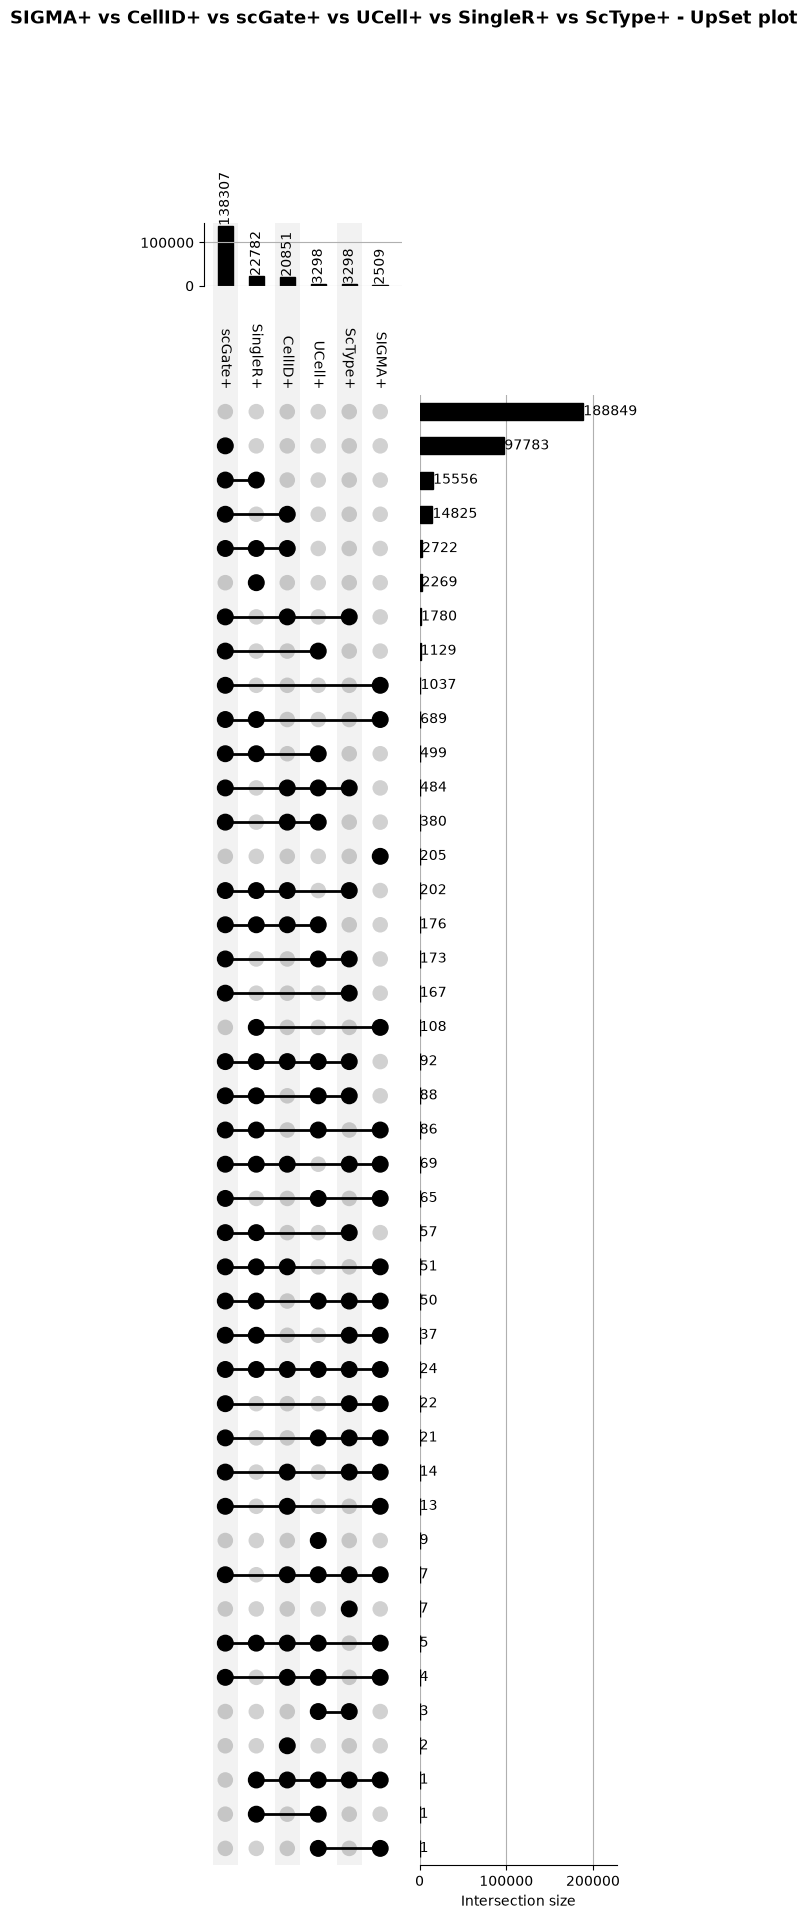

In [9]:
indicators_df = pd.DataFrame({
    "SIGMA+": mask_sigma.values,
    "CellID+": mask_cellid.values,
    "scGate+": mask_scgate.values,
    "UCell+": mask_ucell.values,
    "SingleR+": mask_singler.values,
    "ScType+": mask_sctype.values,
}, index=mask_sigma.index)

upset_data = from_indicators(indicators_df.columns.tolist(), data=indicators_df)

fig = plt.figure(figsize=(8, 9))
upset = UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality",
              orientation="vertical")
upset_axes = upset.plot(fig=fig)
style_upset_axes(upset_axes)
plt.suptitle("SIGMA+ vs CellID+ vs scGate+ vs UCell+ vs SingleR+ vs ScType+ - UpSet plot",
             fontsize=13, fontweight="bold")
# plt.savefig("figures/FIG-upset.pdf", bbox_inches="tight", dpi=500)
plt.show()


---
### Jaccard similarity heatmap (all 6 methods)


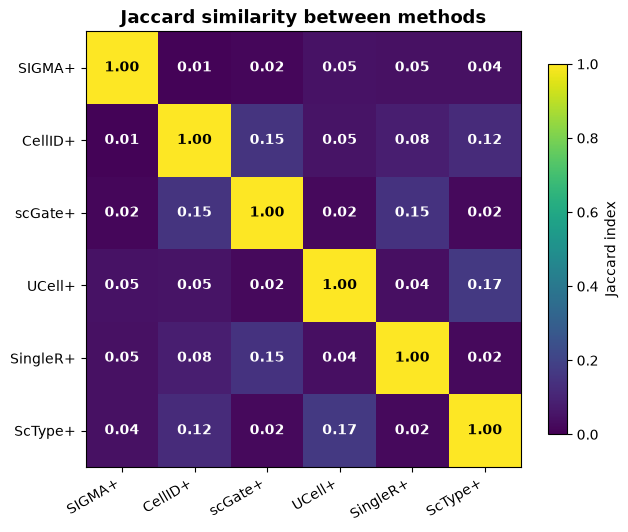

In [10]:
jaccard_masks  = [mask_sigma, mask_cellid, mask_scgate, mask_ucell, mask_singler, mask_sctype]
jaccard_labels = ["SIGMA+", "CellID+", "scGate+", "UCell+", "SingleR+", "ScType+"]
n = len(jaccard_masks)

jaccard_mat = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        a, b = jaccard_masks[i].values, jaccard_masks[j].values
        union = (a | b).sum()
        jaccard_mat[i, j] = (a & b).sum() / union if union > 0 else 0.0

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(jaccard_mat, cmap="viridis", vmin=0, vmax=1)

ax.set_xticks(range(n)); ax.set_xticklabels(jaccard_labels, rotation=30, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(jaccard_labels)

for i in range(n):
    for j in range(n):
        val = jaccard_mat[i, j]
        color = "white" if val < 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=10, fontweight="bold")

ax.set_title("Jaccard similarity between methods", fontsize=13, fontweight="bold")
fig.colorbar(im, ax=ax, label="Jaccard index", shrink=0.8)
plt.tight_layout()
# plt.savefig("figures/FIG-jaccard-heatmap.pdf", bbox_inches="tight", dpi=500)
plt.show()


---
### Mean expression - validation panels (T_CELL_MARKERS vs NON_EFFECTOR_MARKERS), all groups

Uses validation marker panels disjoint from the candidate, target and
exclusion genes that drive the gating itself, which would otherwise be
circular.

AUC = P(a random SIGMA+ cell's mean expression > a random comparator cell's),
with a 95% bootstrap CI; values whose CI falls entirely within +/-0.1 of
0.5 are greyed out (not distinguishable from no effect, regardless of the
near-certain Mann-Whitney significance at these sample sizes). Left panel
(pan-T cell identity, C): higher AUC = SIGMA+ more enriched (expected). Right
panel (non-effector, D): lower AUC = SIGMA+ more depleted (expected).

The non-effector panel (right) is a depletion control, not a discriminating
comparison: terminally differentiated cytotoxic effectors are expected to
be depleted for these markers regardless of method.


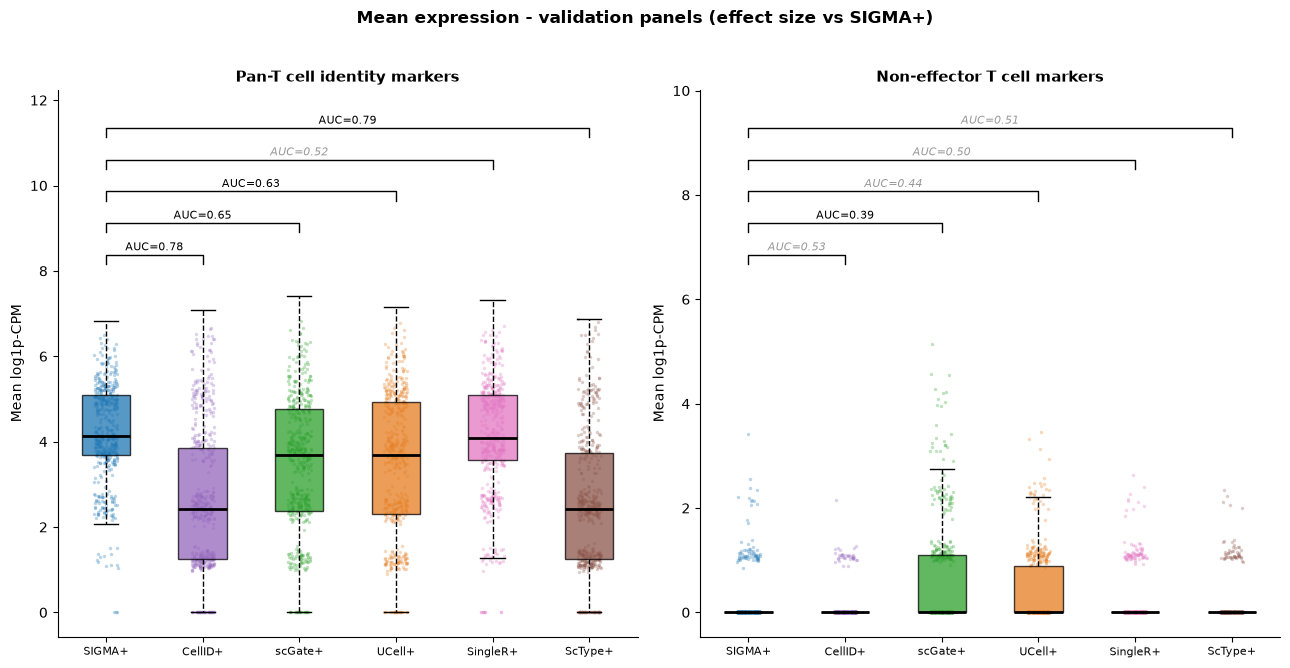

In [11]:
panel_masks  = [mask_sigma, mask_cellid, mask_scgate, mask_ucell, mask_singler, mask_sctype]
panel_labels = ["SIGMA+", "CellID+", "scGate+", "UCell+", "SingleR+", "ScType+"]
panel_colors = [BLUE, PURPLE, GREEN, ORANGE, PINK, BROWN]

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))

values_pos = [mean_panel(adata_norm, m.values, T_CELL_MARKERS) for m in panel_masks]
boxplot_multi_vs_ref(axes[0], values_pos, panel_labels, panel_colors,
                      "Pan-T cell identity markers", np.random.default_rng(SEED), n_sample=500)
axes[0].set_ylabel("Mean log1p-CPM", fontsize=10)

values_neg = [mean_panel(adata_norm, m.values, NON_EFFECTOR_MARKERS) for m in panel_masks]
boxplot_multi_vs_ref(axes[1], values_neg, panel_labels, panel_colors,
                      "Non-effector T cell markers", np.random.default_rng(SEED), n_sample=500)
axes[1].set_ylabel("Mean log1p-CPM", fontsize=10)

fig.suptitle("Mean expression - validation panels (effect size vs SIGMA+)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
# plt.savefig("figures/FIG-validation-panels.pdf", bbox_inches="tight", dpi=500)
plt.show()


---
## Composition / purity stacked bars per method

Purely descriptive: no gold standard and no recall claim. For each method's
own called-positive population (SIGMA+, CellID+, scGate+, UCell+, SingleR+,
ScType+), we count how many of 3 independent criteria each cell passes:
- `T_CELL_MARKERS` high (Otsu cutoff)
- `NON_EFFECTOR_MARKERS` low (Otsu cutoff)
- `NK_MARKERS` low (Otsu cutoff)

All three cutoffs are Otsu thresholds fit on the full atlas. All three
panels are zero-inflated (most cells express none of these markers at all),
so Otsu's 2-class assumption is not fully satisfied for any of them - the
robustness of the ranking below to this threshold choice is checked in the
threshold sensitivity check further down, applying 4 candidate
thresholding rules to all three panels simultaneously, including a
deliberately mis-specified stress test.

"Triple-clean" = passes all 3. "Partially contaminated" = fails exactly 1.
"Off-target" = fails 2 or 3. This describes *what each method actually
called*, not what it might have missed.


In [12]:
# All three panels below are zero-inflated (most of this cross-tissue atlas
# does not express T/NK/non-effector markers at all), so Otsu's 2-class
# assumption is not fully satisfied for any of them - the sensitivity
# analysis below checks whether the SIGMA+ vs other-methods ranking is
# robust across 4 candidate thresholding choices applied to all three
# panels simultaneously, including a deliberately mis-specified stress test.
score_tcell        = panel_score(T_CELL_MARKERS)
score_non_effector = panel_score(NON_EFFECTOR_MARKERS)
score_nk           = panel_score(NK_MARKERS)

otsu_tcell        = threshold_otsu(score_tcell)
otsu_non_effector = threshold_otsu(score_non_effector)
otsu_nk           = threshold_otsu(score_nk)

criteria_pass = pd.DataFrame({
    "tcell_ok":        score_tcell >= otsu_tcell,
    "non_effector_ok": score_non_effector < otsu_non_effector,
    "nk_ok":           score_nk < otsu_nk,
}, index=adata_norm.obs_names)

print(f"Thresholds used (Otsu, all cells) - T_CELL_MARKERS >= {otsu_tcell:.2f}, "
      f"NON_EFFECTOR_MARKERS < {otsu_non_effector:.2f}, NK_MARKERS < {otsu_nk:.2f}")


Thresholds used (Otsu, all cells) - T_CELL_MARKERS >= 2.48, NON_EFFECTOR_MARKERS < 1.54, NK_MARKERS < 2.53


---
### Stacked bar plot


               N  Triple-clean  Partially contaminated  Off-target
Method                                                            
SIGMA+      2509          66.8                    30.9         2.3
CellID+    20851           1.8                    44.9        53.3
scGate+   138307          40.2                    40.4        19.4
UCell+      3298          22.0                    50.5        27.5
SingleR+   22782          53.8                    44.0         2.2
ScType+     3298           8.0                    40.6        51.3


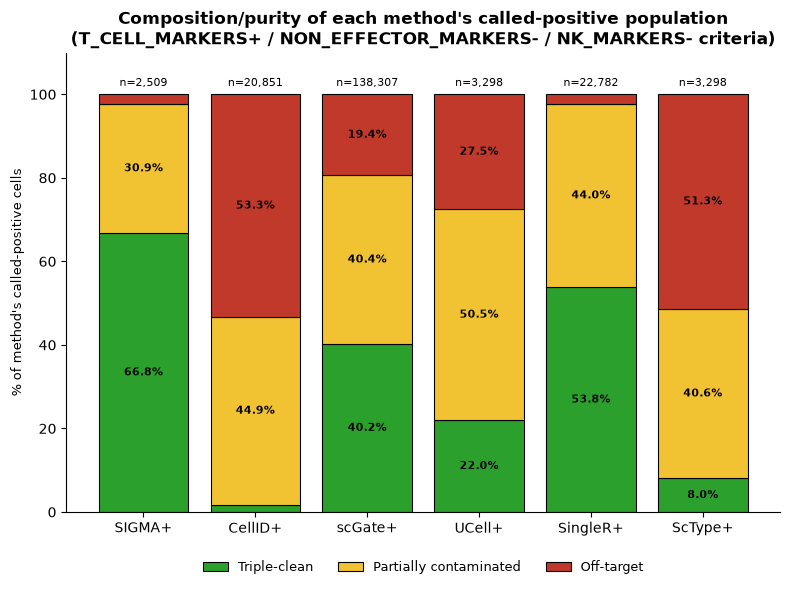

In [13]:
method_masks_full = {
    "SIGMA+":  mask_sigma.values,
    "CellID+": mask_cellid.values,
    "scGate+": mask_scgate.values,
    "UCell+":  mask_ucell.values,
    "SingleR+": mask_singler.values,
    "ScType+": mask_sctype.values,
}
method_labels = ["SIGMA+", "CellID+", "scGate+", "UCell+", "SingleR+", "ScType+"]

composition_df = composition_purity_table(criteria_pass, method_masks_full, method_labels)
print(composition_df.round(1))

fig, ax = plt.subplots(figsize=(8, 6))
plot_composition_purity(ax, composition_df)
ax.set_title("Composition/purity of each method's called-positive population\n"
             "(T_CELL_MARKERS+ / NON_EFFECTOR_MARKERS- / NK_MARKERS- criteria)",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=9, frameon=False)
plt.tight_layout()
# plt.savefig("figures/FIG-purity-stacked.pdf", bbox_inches="tight", dpi=500)
plt.show()


---
### Threshold sensitivity check for the composition/purity panel

`T_CELL_MARKERS`, `NON_EFFECTOR_MARKERS` and `NK_MARKERS` are all
zero-inflated in this cross-tissue atlas (most cells express none of these
markers at all), so Otsu's 2-class assumption is not fully satisfied for
any of them, and a 2-component GMM can disagree substantially with Otsu on
a zero-inflated distribution (see the per-scenario thresholds printed
below). Rather than pick a single "correct" threshold, we check whether the
method ranking above is robust to the choice of thresholding rule, applying
the same rule to all three panels at once across 4 candidate scenarios:

1. **Otsu (all cells)** - the scenario used for the figure above.
2. **Otsu (score > 0 only)** - excludes the trivial zero spike before fitting.
3. **GMM (score > 0 only)** - the best-specified 2-component fit (the zero
   spike is excluded, so both components correspond to real expression
   levels rather than one component capturing "expresses nothing").
4. **GMM (all cells) - stress test** - deliberately mis-specified: fitting 2
   components to a distribution dominated by a zero spike pulls one
   component to ~0, so this scenario is not a valid threshold choice, only
   a check of how far a bad threshold can move the numbers.

If the SIGMA+ vs comparator-method ranking holds across all 4, including
the stress test, the composition/purity conclusions do not depend on this
threshold choice.


In [14]:
def gmm_threshold(scores, seed=42):
    """2-component GMM threshold: midpoint where the high-mean component's
    posterior probability crosses 0.5."""
    gmm = GaussianMixture(n_components=2, random_state=seed, n_init=5)
    gmm.fit(scores.reshape(-1, 1))
    means = gmm.means_.flatten()
    high_comp = np.argsort(means)[1]
    xs = np.linspace(scores.min(), scores.max(), 2000)
    post = gmm.predict_proba(xs.reshape(-1, 1))[:, high_comp]
    return xs[np.argmin(np.abs(post - 0.5))]

def thresholds_for_rule(rule):
    """T_CELL/NON_EFFECTOR/NK thresholds for one of the 4 sensitivity rules,
    applied identically to all three panels."""
    if rule == "otsu_all":
        return (threshold_otsu(score_tcell), threshold_otsu(score_non_effector),
                threshold_otsu(score_nk))
    if rule == "otsu_nonzero":
        return (threshold_otsu(score_tcell[score_tcell > 0]),
                threshold_otsu(score_non_effector[score_non_effector > 0]),
                threshold_otsu(score_nk[score_nk > 0]))
    if rule == "gmm_nonzero":
        return (gmm_threshold(score_tcell[score_tcell > 0]),
                gmm_threshold(score_non_effector[score_non_effector > 0]),
                gmm_threshold(score_nk[score_nk > 0]))
    if rule == "gmm_all":
        return (gmm_threshold(score_tcell), gmm_threshold(score_non_effector),
                gmm_threshold(score_nk))
    raise ValueError(rule)

def composition_for_rule(tcell_t, non_effector_t, nk_t):
    criteria = pd.DataFrame({
        "tcell_ok":        score_tcell >= tcell_t,
        "non_effector_ok": score_non_effector < non_effector_t,
        "nk_ok":           score_nk < nk_t,
    }, index=adata_norm.obs_names)
    return composition_purity_table(criteria, method_masks_full, method_labels)

scenarios = [
    ("1. Otsu (all cells) - used for the figure above", "otsu_all"),
    ("2. Otsu (score>0 only)", "otsu_nonzero"),
    ("3. GMM (score>0 only) - best-specified fit", "gmm_nonzero"),
    ("4. GMM (all cells) - stress test, deliberately mis-specified", "gmm_all"),
]

sensitivity_results = {}
for label, rule in scenarios:
    tcell_t, non_effector_t, nk_t = thresholds_for_rule(rule)
    df = composition_for_rule(tcell_t, non_effector_t, nk_t)
    sensitivity_results[label] = df
    print(f"\n--- {label} ---")
    print(f"    (T_CELL >= {tcell_t:.2f}, NON_EFFECTOR < {non_effector_t:.2f}, NK < {nk_t:.2f})")
    print(df[["N", "Triple-clean", "Off-target"]].round(1))

print("\n--- Off-target % ranking per scenario ---")
for label, df in sensitivity_results.items():
    ranked = df["Off-target"].round(1).sort_values()
    print(f"  {label}:\n    " + " < ".join(f"{m}({v})" for m, v in ranked.items()))

print(f"\nSIGMA+ Off-target % across all 4 scenarios: "
      f"{[round(sensitivity_results[l].loc['SIGMA+', 'Off-target'], 1) for l in sensitivity_results]}")

sensitivity_export = pd.concat(sensitivity_results, names=["Scenario", "Method"])
sensitivity_export.to_csv(os.path.join(RESULTS_DIR, "dominguez_threshold_sensitivity.csv"))
print(f"\nSaved sensitivity table to {os.path.join(RESULTS_DIR, 'dominguez_threshold_sensitivity.csv')}")



--- 1. Otsu (all cells) - used for the figure above ---
    (T_CELL >= 2.48, NON_EFFECTOR < 1.54, NK < 2.53)
               N  Triple-clean  Off-target
Method                                    
SIGMA+      2509          66.8         2.3
CellID+    20851           1.8        53.3
scGate+   138307          40.2        19.4
UCell+      3298          22.0        27.5
SingleR+   22782          53.8         2.2
ScType+     3298           8.0        51.3

--- 2. Otsu (score>0 only) ---
    (T_CELL >= 3.10, NON_EFFECTOR < 1.91, NK < 3.39)
               N  Triple-clean  Off-target
Method                                    
SIGMA+      2509          67.4         2.2
CellID+    20851           2.8        67.5
scGate+   138307          38.4        21.7
UCell+      3298          25.4        31.8
SingleR+   22782          52.4         3.2
ScType+     3298           9.2        65.6

--- 3. GMM (score>0 only) - best-specified fit ---
    (T_CELL >= 2.66, NON_EFFECTOR < 1.43, NK < 2.08)
            

---
### Mean expression - NK_MARKERS panel (NK contamination), all groups

AUC = P(a random SIGMA+ cell's mean expression > a random comparator
cell's), with a 95% bootstrap CI; lower AUC = SIGMA+ more depleted
(expected, since this panel is a contamination marker). Values whose CI
falls entirely within +/-0.1 of 0.5 are greyed out.


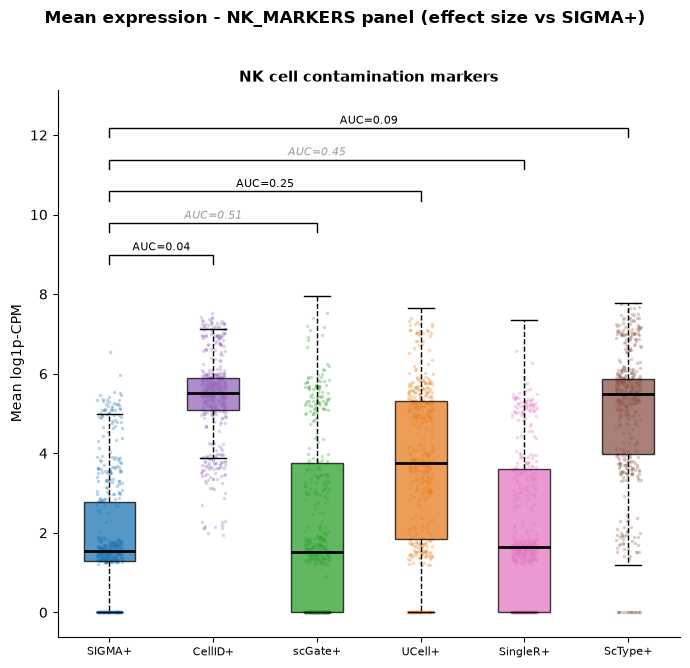

In [15]:
panel_masks  = [mask_sigma, mask_cellid, mask_scgate, mask_ucell, mask_singler, mask_sctype]
panel_labels = ["SIGMA+", "CellID+", "scGate+", "UCell+", "SingleR+", "ScType+"]
panel_colors = [BLUE, PURPLE, GREEN, ORANGE, PINK, BROWN]

fig, ax = plt.subplots(figsize=(7, 6.5))

values_nk = [mean_panel(adata_norm, m.values, NK_MARKERS) for m in panel_masks]
boxplot_multi_vs_ref(ax, values_nk, panel_labels, panel_colors,
                      "NK cell contamination markers", np.random.default_rng(SEED), n_sample=500)
ax.set_ylabel("Mean log1p-CPM", fontsize=10)

fig.suptitle("Mean expression - NK_MARKERS panel (effect size vs SIGMA+)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
# plt.savefig("figures/FIG-nk-panel.pdf", bbox_inches="tight", dpi=500)
plt.show()


---
### Supplementary: exclusion-compliance diagnostic (not a validation panel)

`EXCLUSION_COMPLIANCE_MARKERS = ["CD4", "FOXP3", "TCF7", "SELL"]` overlaps
3 of 4 genes with `EXCLUSION_GENES` (`FOXP3`, `TCF7`, `SELL`) - by
construction, any method that actually implements exclusion should score
low here, since these genes are literally what it is excluding on. This
panel therefore cannot serve as independent evidence that called-positive
cells are biologically non-cytotoxic (that is what `NON_EFFECTOR_MARKERS`,
a disjoint panel, is for above). What it *can* show is a sanity check that
each method's exclusion mechanism is doing what it claims: a method whose
called-positive population still scores high on its own exclusion genes
would indicate the exclusion step is not working as intended.

AUC = P(a random SIGMA+ cell's score > a random comparator cell's), with a
95% bootstrap CI; lower AUC = SIGMA+ scores lower on its own exclusion
genes (expected, if exclusion is working). Values whose CI falls entirely
within +/-0.1 of 0.5 are greyed out.


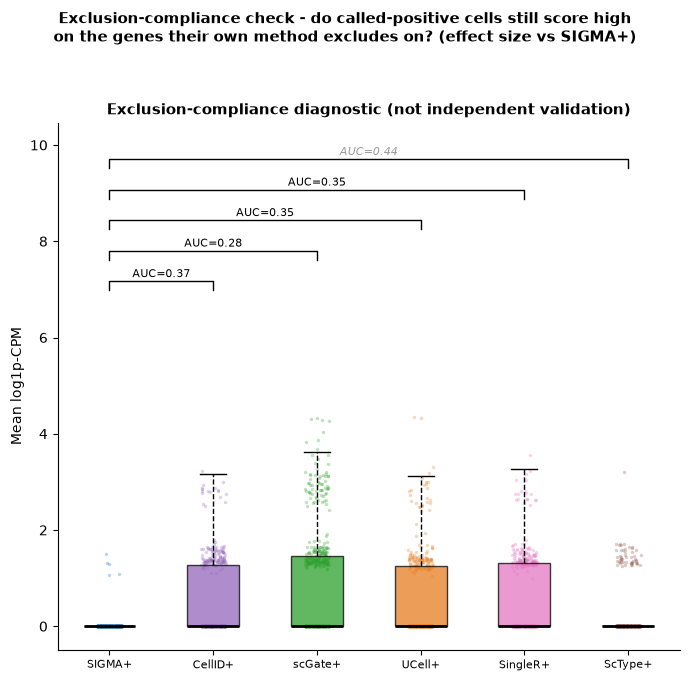

In [16]:
values_diag = [mean_panel(adata_norm, m.values, EXCLUSION_COMPLIANCE_MARKERS) for m in panel_masks]

fig, ax = plt.subplots(figsize=(7, 6.5))
boxplot_multi_vs_ref(ax, values_diag, panel_labels, panel_colors,
                      "Exclusion-compliance diagnostic (not independent validation)",
                      np.random.default_rng(SEED), n_sample=500)
ax.set_ylabel("Mean log1p-CPM", fontsize=10)

fig.suptitle("Exclusion-compliance check - do called-positive cells still score high\n"
             "on the genes their own method excludes on? (effect size vs SIGMA+)",
             fontsize=11, fontweight="bold", y=1.04)
plt.tight_layout()
# plt.savefig("figures/FIG-exclusion-compliance.pdf", bbox_inches="tight", dpi=500)
plt.show()


---
### Supplementary: candidate-prefilter effect (not a validation panel)

`CANDIDATE_GENES = ["CD3E", "TRAC", "CD8A", "CD8B"]` is the `[Candidate]`
section of `config/StudyCaseDominguez.conf`. SIGMA scores only cells in which
at least 3 of these 4 genes reach 2 raw counts; none of the five comparators
has an equivalent step. SIGMA+ is therefore advantaged here by construction,
which is precisely why this panel cannot serve as independent validation - that
is what the pan-T identity panel above is for.

What it *can* show is the size of the effect that prefilter has: how much
T-lineage evidence the comparator selections contain once no such gate is
applied. This is the mechanistic explanation of the identity results, not
evidence for them.

AUC = P(a random SIGMA+ cell's score > a random comparator cell's), with a 95%
bootstrap CI. Values whose CI falls entirely within +/-0.1 of 0.5 are greyed
out.


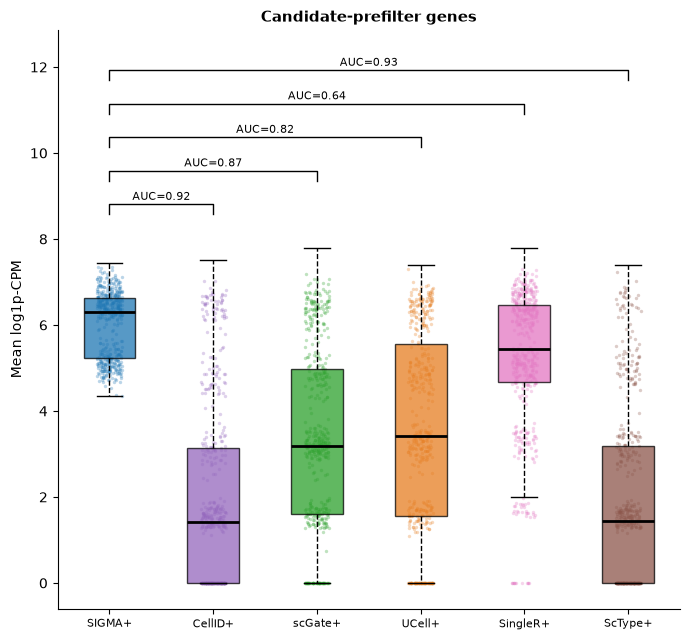

In [20]:
values_cand = [mean_panel(adata_norm, m.values, CANDIDATE_GENES) for m in panel_masks]

fig, ax = plt.subplots(figsize=(7, 6.5))
boxplot_multi_vs_ref(ax, values_cand, panel_labels, panel_colors,
                      "Candidate-prefilter genes",
                      np.random.default_rng(SEED), n_sample=500)
ax.set_ylabel("Mean log1p-CPM", fontsize=10)
plt.tight_layout()
# plt.savefig("figures/FIG-candidate-prefilter.pdf", bbox_inches="tight", dpi=500)
plt.show()


---
### Combined comparison figure (A-G)

Merges 6 of the 7 figures above into a single composite panel (the
exclusion-compliance diagnostic just above is intentionally excluded, since
it is not part of the validation argument):
UpSet plot (A), Jaccard heatmap (B), T cell identity markers (C),
Non-effector T cell markers (D), NK contamination markers (E),
candidate-prefilter genes (F), and composition/purity stacked bars (G).


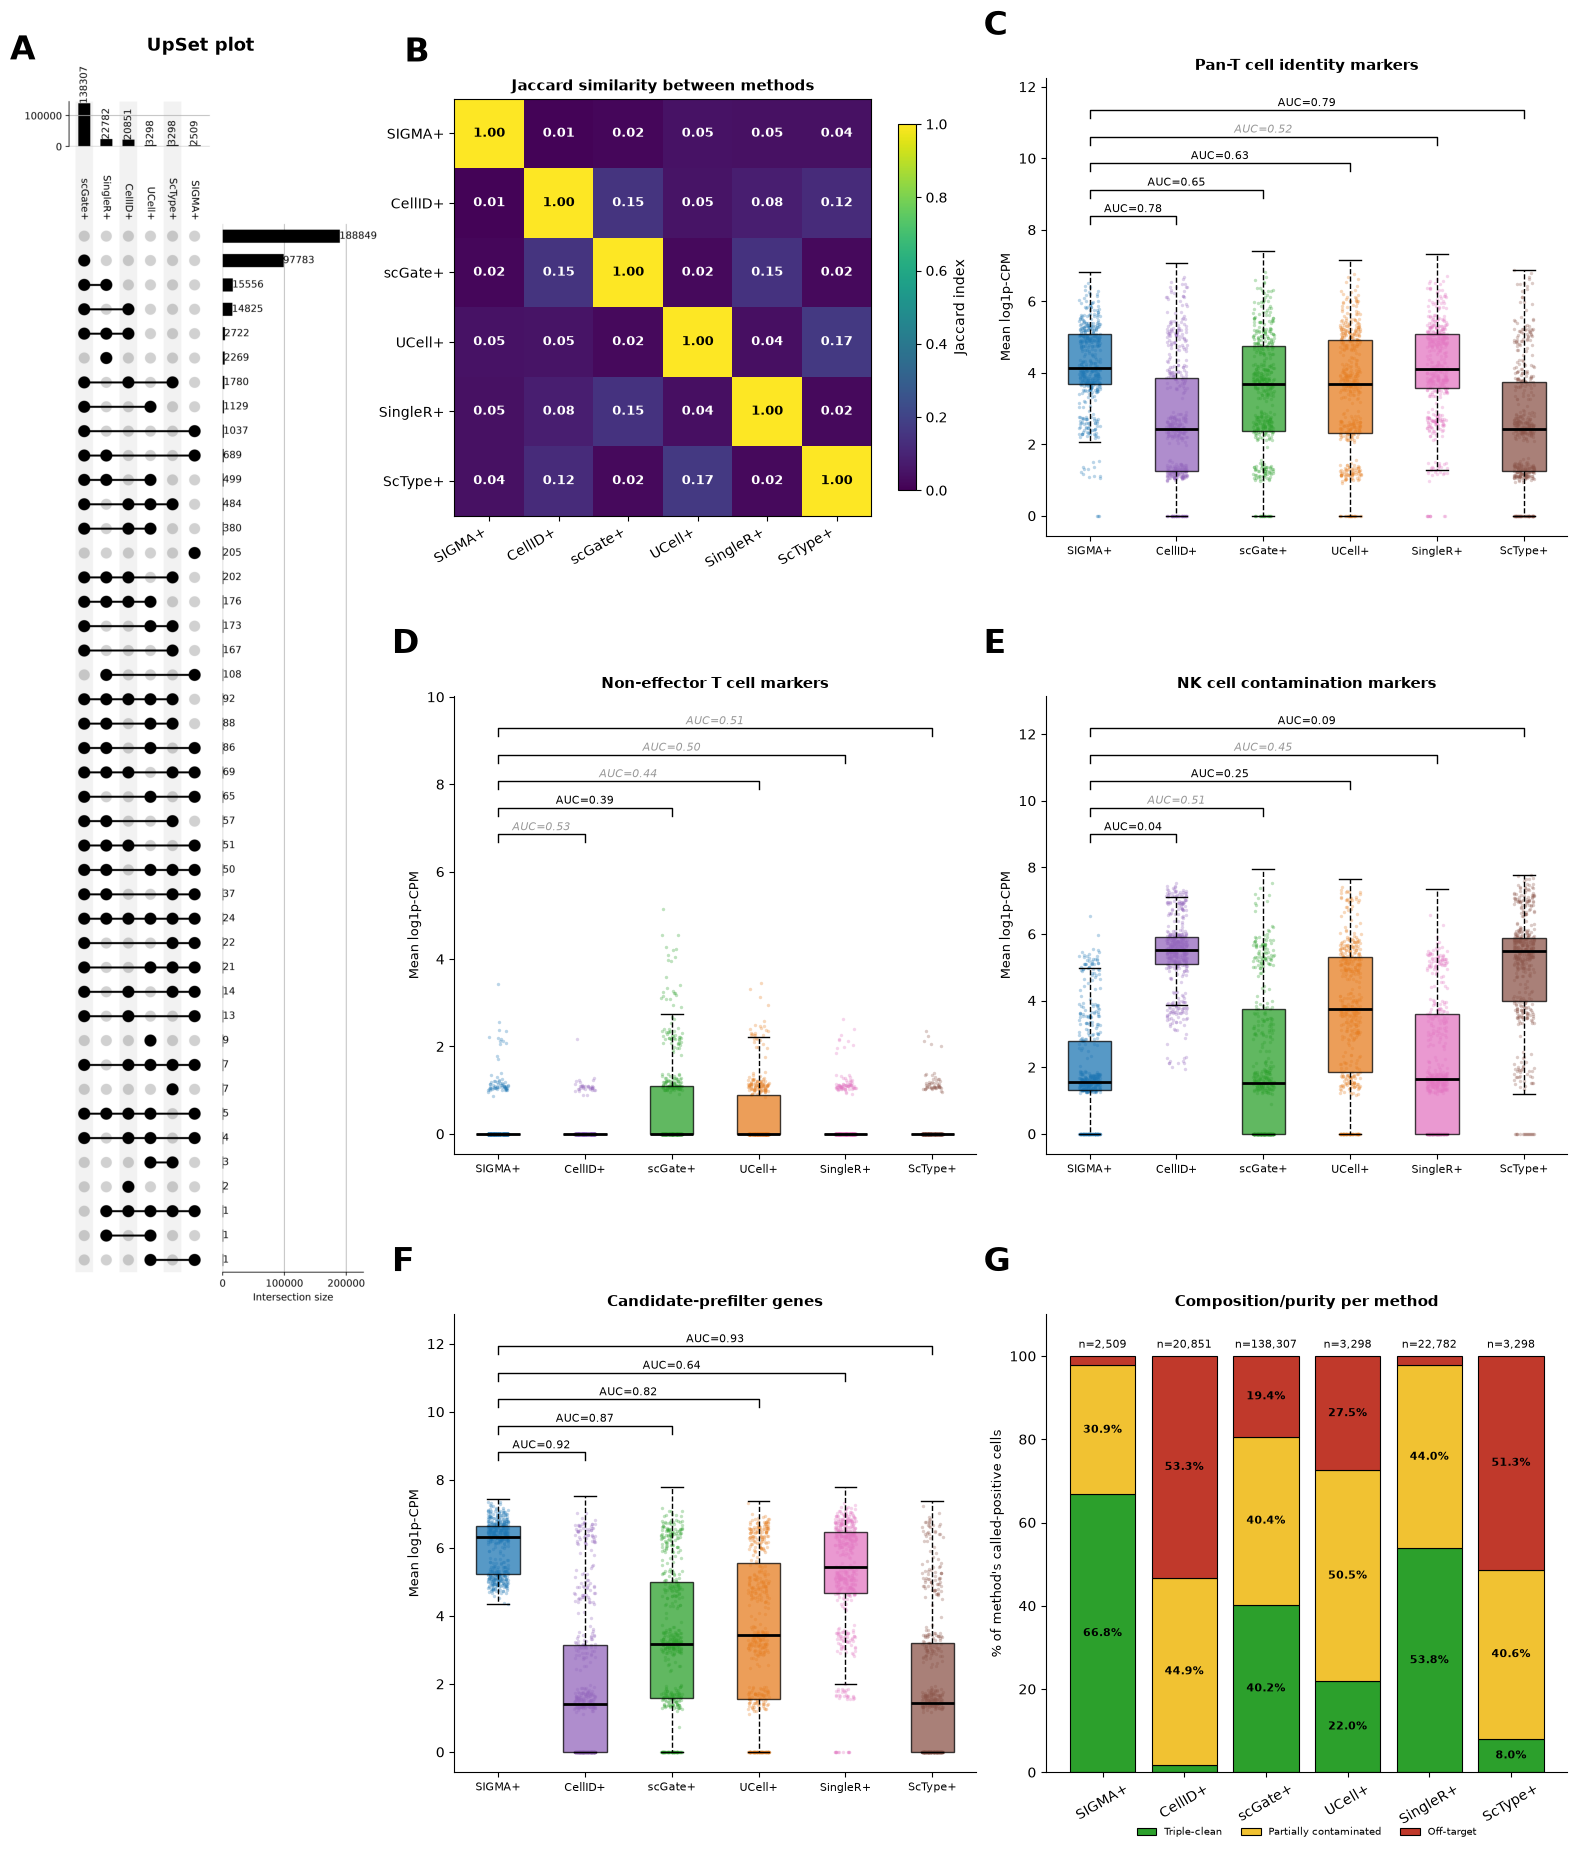

In [32]:
# A - UpSet plot (rendered standalone, embedded as image), spans all 3 rows
# of its column since it needs more room to stay legible than the other panels.
indicators_df = pd.DataFrame({
    "SIGMA+": mask_sigma.values,
    "CellID+": mask_cellid.values,
    "scGate+": mask_scgate.values,
    "UCell+": mask_ucell.values,
    "SingleR+": mask_singler.values,
    "ScType+": mask_sctype.values,
}, index=mask_sigma.index)
upset_data = from_indicators(indicators_df.columns.tolist(), data=indicators_df)
upset_fig = plt.figure(figsize=(8, 12))
upset = UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality",
              orientation="vertical")
upset_axes = upset.plot(fig=upset_fig)
style_upset_axes(upset_axes)
buf = io.BytesIO()
upset_fig.savefig(buf, format="png", bbox_inches="tight", dpi=500)
plt.close(upset_fig)
buf.seek(0)
upset_img = plt.imread(buf)

fig = plt.figure(figsize=(20, 22))
img_h, img_w = upset_img.shape[:2]
col0_ratio = (img_w / img_h) * 2.4  # = (img_w/img_h) * 16in * 3 / (20in/3 per col)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.15,
                        width_ratios=[col0_ratio, 1, 1])

axA = fig.add_subplot(gs[:, 0])
axA.imshow(upset_img)
axA.axis("off")
axA.set_title("UpSet plot", fontsize=13, fontweight="bold")
axA.text(-0.02, 1.02, "A", transform=axA.transAxes, fontsize=24, fontweight="bold", va="top")

# B - Jaccard similarity heatmap
axB = fig.add_subplot(gs[0, 1])
jaccard_masks  = [mask_sigma, mask_cellid, mask_scgate, mask_ucell, mask_singler, mask_sctype]
jaccard_labels = ["SIGMA+", "CellID+", "scGate+", "UCell+", "SingleR+", "ScType+"]
n = len(jaccard_masks)
jaccard_mat = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        a, b = jaccard_masks[i].values, jaccard_masks[j].values
        union = (a | b).sum()
        jaccard_mat[i, j] = (a & b).sum() / union if union > 0 else 0.0
im = axB.imshow(jaccard_mat, cmap="viridis", vmin=0, vmax=1)
axB.set_xticks(range(n)); axB.set_xticklabels(jaccard_labels, rotation=30, ha="right")
axB.set_yticks(range(n)); axB.set_yticklabels(jaccard_labels)
for i in range(n):
    for j in range(n):
        val = jaccard_mat[i, j]
        color = "white" if val < 0.5 else "black"
        axB.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=9, fontweight="bold")
axB.set_title("Jaccard similarity between methods", fontsize=11, fontweight="bold")
fig.colorbar(im, ax=axB, label="Jaccard index", shrink=0.8)
axB.text(-0.12, 1.15, "B", transform=axB.transAxes, fontsize=24, fontweight="bold", va="top")

# C, D, E - validation panels (T_CELL_MARKERS, NON_EFFECTOR_MARKERS, NK_MARKERS) vs SIGMA+
panel_masks  = [mask_sigma, mask_cellid, mask_scgate, mask_ucell, mask_singler, mask_sctype]
panel_labels = ["SIGMA+", "CellID+", "scGate+", "UCell+", "SingleR+", "ScType+"]
panel_colors = [BLUE, PURPLE, GREEN, ORANGE, PINK, BROWN]

for (row, col), genes, letter, title in [
    ((0, 2), T_CELL_MARKERS, "C", "Pan-T cell identity markers"),
    ((1, 1), NON_EFFECTOR_MARKERS, "D", "Non-effector T cell markers"),
    ((1, 2), NK_MARKERS,     "E", "NK cell contamination markers"),
]:
    ax = fig.add_subplot(gs[row, col])
    values = [mean_panel(adata_norm, m.values, genes) for m in panel_masks]
    # Fresh rng per panel (same seed as the matching standalone figure), so
    # each panel is reproducible independent of which figure it appears in
    # - the combined figure's C/D/E panels then match their standalone
    # counterparts' bootstrap CIs (and negligible-effect greying) exactly.
    boxplot_multi_vs_ref(ax, values, panel_labels, panel_colors, title,
                          np.random.default_rng(SEED), n_sample=500)
    ax.set_ylabel("Mean log1p-CPM", fontsize=9)
    ax.text(-0.12, 1.15, letter, transform=ax.transAxes, fontsize=24, fontweight="bold", va="top")

# F - candidate-prefilter genes boxplot
axF = fig.add_subplot(gs[2, 1])
values_cand = [mean_panel(adata_norm, m.values, CANDIDATE_GENES) for m in panel_masks]
boxplot_multi_vs_ref(axF, values_cand, panel_labels, panel_colors,
                      "Candidate-prefilter genes", np.random.default_rng(SEED), n_sample=500)
axF.set_ylabel("Mean log1p-CPM", fontsize=9)
axF.text(-0.12, 1.15, "F", transform=axF.transAxes, fontsize=24, fontweight="bold", va="top")

# G - composition/purity stacked bars
axG = fig.add_subplot(gs[2, 2])
plot_composition_purity(axG, composition_df)
axG.set_title("Composition/purity per method", fontsize=11, fontweight="bold")
axG.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=7, frameon=False)
axG.tick_params(axis="x", labelrotation=30)
axG.text(-0.12, 1.15, "G", transform=axG.transAxes, fontsize=24, fontweight="bold", va="top")


fig.canvas.draw()
posA = axA.get_position()
posB = axB.get_position()
img_aspect = img_h / img_w  # height / width of the embedded UpSet image
new_h = posA.width * (fig.get_figwidth() / fig.get_figheight()) * img_aspect
top = posB.y1 + 0.018
axA.set_position([posA.x0, top - new_h, posA.width, new_h])

fig.savefig("figures/sup-comparison.pdf", bbox_inches="tight", dpi=500)
plt.show()


---
## Cleanup

Remove the on-disk counts transfer written to `SCRATCH_DIR` during scoring
(~12 GB of `.mtx`). The scoring results themselves are already persisted to
`results/dominguez_scores.parquet` above, so nothing needed downstream is lost.


In [19]:
if os.path.isdir(SCRATCH_DIR):
    shutil.rmtree(SCRATCH_DIR)
    print(f"Removed scratch transfer dir: {SCRATCH_DIR}")
else:
    print(f"Nothing to remove (already absent): {SCRATCH_DIR}")


Removed scratch transfer dir: /home/lemgui01/sigma_scratch/dominguez_transfer
